# Tattersalls Autumn Horses in Training Sale — Exploratory Data Analysis


This notebook provides a structured exploration of the Tattersalls Autumn Horses in Training
Sale dataset (2009–2025, 26 076 lots). The analysis is organised in seven sections:

| § | Topic |
|---|-------|
| 1 | Dataset Scope & Macroeconomic Context |
| 2 | Overall Market Outcomes |
| 3 | Temporal Dynamics & Hurdle Analysis |
| 4 | Horse Characteristics |
| 5 | Pedigree & Connections |
| 6 | Noise Audit & Feature Selection |
| 7 | Handoff to Modelling |

All visualisations are stored under `outputs/`. Statistical conclusions precede each modelling
decision documented in `03_FeatureEngineering.ipynb`.

## 0. Setup & Data Loading

Loads the processed dataset from `data/processed/clean_data.parquet` and, where available,
the external stallion earnings dataset. Macroeconomic variables (CPI, GBP/EUR) are pulled
live via `onspy` for real-price deflation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('').resolve()))
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.data_prep import get_macro_data

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import onspy
import scipy.stats as stats
plt.rcParams['axes.formatter.limits'] = (-20, 20)
plt.rcParams['axes.formatter.useoffset'] = False
sns.set_style('whitegrid')
df_sold = pd.read_parquet('../data/processed/clean_data.parquet')
autumn_horses_df = df_sold.copy()
df_offered = autumn_horses_df[autumn_horses_df['is_offered_for_sale']].copy()
PREMIUM_CUTOFF = 150000
by_year = (
    autumn_horses_df.groupby("sale_year")
    .agg(
        total_catalogued=("lot", "size"),
        offered=("is_offered_for_sale", "sum"),
        sold_to_third_party=("sold_to_third_party", "sum"),
        vendor_buyback=("vendor_buyback", "sum"),
        lot_not_sold=("lot_not_sold", "sum"),
        withdrawn=("lot_withdrawn", "sum"),
        median_price_sold=("price_gns", lambda s: s[autumn_horses_df.loc[s.index, "sold_to_third_party"]].median())
    )
)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
# Global Analytical Constants
PREMIUM_CUTOFF = 150000  # 150k guineas: market threshold for high-value lots
EARLY_PERIOD = (2009, 2015)
MID_PERIOD = (2016, 2020)
RECENT_PERIOD = (2021, 2025)
cpi_october = {
    2009: 89.2, 2010: 91.9, 2011: 96.5, 2012: 99.1, 2013: 101.3, 2014: 102.6,
    2015: 102.6, 2016: 103.5, 2017: 106.6, 2018: 109.2, 2019: 110.8, 2020: 111.8,
    2021: 116.5, 2022: 129.4, 2023: 135.5, 2024: 138.6, 2025: 141.4  # Estimate for 2025
}
BASE_YEAR = 2024
COUNTRY_SUFFIX_RE = re.compile(r'\s*\(([A-Z]+)\)\s*$')
def extract_country_suffix(series: pd.Series) -> pd.Series:
    """Extract country codes such as (GB) without destroying the original string."""
    return series.astype('string').str.extract(COUNTRY_SUFFIX_RE, expand=False)
def strip_country_suffix(series: pd.Series) -> pd.Series:
    """Remove country suffixes such as (GB) while keeping the full entity name."""
    return series.astype('string').str.replace(COUNTRY_SUFFIX_RE, '', regex=True).str.strip()
def parse_numeric_series(series: pd.Series) -> pd.Series:
    """Parse Tattersalls-style numeric fields like 90.000 or 108.675 into floats."""
    cleaned = (
        series.astype('string')
        .str.strip()
        .replace({'-': pd.NA, 'nan': pd.NA, 'None': pd.NA, '': pd.NA}) # type: ignore
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    return pd.to_numeric(cleaned, errors='coerce')
def title_from_canonical(series: pd.Series) -> pd.Series:
    """Convert canonical uppercase labels into a readable title-case display string."""
    return (
        series.astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
        .str.title()
    )
def normalize_root_entity(name: str, stopwords=None, aliases=None):
    """Conservative normalization for high-cardinality entity names."""
    if pd.isna(name):
        return None
    stopwords = stopwords or set()
    aliases = aliases or {}
    s = str(name).upper().strip()
    s = aliases.get(s, s)
    s = s.replace('&', ' AND ')
    s = re.sub(r'[^A-Z0-9\s]', ' ', s)
    tokens = [t for t in s.split() if t not in stopwords]
    s = ' '.join(tokens)
    s = re.sub(r'\s+', ' ', s).strip()
    return s if s else None
def bootstrap_ci(values, stat_func=np.median, n_boot=2000, ci=0.95, random_state=42):
    """
    Bootstrap confidence interval for a univariate statistic.
    Vectorized implementation for efficiency with large samples.
    Parameters:
    -----------
    values : array-like
        Data to bootstrap
    stat_func : callable
        Statistic function (default: np.median for robustness with heavy tails)
    n_boot : int
        Number of bootstrap samples (default: 2000)
    ci : float
        Confidence level (default: 0.95)
    random_state : int
        Random seed for reproducibility
    Returns:
    --------
    tuple : (observed_statistic, ci_lower, ci_upper)
    Notes:
    ------
    Uses percentile method. For n > 4000 with median or proportions,
    this converges to BCa method (Efron & Tibshirani, 1993).
    For small samples (n < 500) with asymmetric distributions,
    consider using scipy.stats.bootstrap with method='BCa'.
    """
    clean = pd.Series(values).dropna().astype(float).to_numpy()
    if clean.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(random_state)
    # Vectorized sampling: generate all bootstrap samples at once
    # Shape: (n_boot, clean.size)
    boot_samples = rng.choice(clean, size=(n_boot, clean.size), replace=True)
    # Apply statistic to each bootstrap sample
    # Optimization: use axis-specific functions when possible (avoids apply_along_axis overhead)
    if stat_func == np.median:
        boot_stats = np.median(boot_samples, axis=1)
    elif stat_func == np.mean:
        boot_stats = np.mean(boot_samples, axis=1)
    elif stat_func == np.std:
        boot_stats = np.std(boot_samples, axis=1, ddof=1)
    else:
        # Fallback for custom functions (e.g., trimmed mean, quantiles)
        boot_stats = np.apply_along_axis(stat_func, 1, boot_samples)
    observed = stat_func(clean)
    alpha = (1 - ci) / 2
    return observed, np.quantile(boot_stats, alpha), np.quantile(boot_stats, 1 - alpha)
def bootstrap_proportion_ci(boolean_values, n_boot=2000, ci=0.95, random_state=42):
    """
    Bootstrap confidence interval for a binary proportion.
    Vectorized implementation using binomial sampling optimization.
    Parameters:
    -----------
    boolean_values : array-like
        Binary data (0/1 or True/False)
    n_boot : int
        Number of bootstrap samples (default: 2000)
    ci : float
        Confidence level (default: 0.95)
    random_state : int
        Random seed for reproducibility
    Returns:
    --------
    tuple : (observed_proportion, ci_lower, ci_upper)
    Notes:
    ------
    For proportions with n > 5000, the percentile method is 
      approximately equivalent to BCa due to CLT convergence.
     Mathematical note: The bootstrap distribution of a proportion 
      is approximately symmetric when n*p and n*(1-p) > 10.
    """
    clean = pd.Series(boolean_values).dropna().astype(int).to_numpy()
    if clean.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(random_state)
    # Vectorized approach: generate all samples at once
    # Shape: (n_boot, clean.size)
    boot_samples = rng.choice(clean, size=(n_boot, clean.size), replace=True)
    # Calculate proportion for each bootstrap sample
    # Sum along axis=1 gives count of 1s, divide by n gives proportion
    boot_props = boot_samples.sum(axis=1) / clean.size
    observed_prop = clean.mean()
    alpha = (1 - ci) / 2
    return observed_prop, np.quantile(boot_props, alpha), np.quantile(boot_props, 1 - alpha)
def permutation_test(values_a, values_b, stat_func=np.median, n_perm=5000, random_state=42):
    """
    Two-sided permutation test for a difference in statistics.
    Tests the null hypothesis that two groups have the same distribution 
     (specifically, that their statistics are equal).
    Parameters:
    ----------
    values_a : array-like
        First group data
    values_b : array-like
        Second group data
    stat_func : callable
        Statistic function to compare (default: np.median for robustness)
    n_perm : int
        Number of permutations (default: 5000)
    random_state : int
        Random seed for reproducibility
    Returns:
    --------
    tuple : (observed_difference, p_value)
    Notes:
    -----
    The permutation test is exact (not approximate) under H₀,
     making it more robust than parametric tests for heavy-tailed data.
    Assumptions:
     - Exchangeability under H₀: if groups come from the same distribution,
        any permutation is equally likely
     - Independence within and between groups
    For heavy-tailed data with different tail behaviors,
     consider using robust statistics like median or trimmed mean.
    """
    a = pd.Series(values_a).dropna().astype(float).to_numpy()
    b = pd.Series(values_b).dropna().astype(float).to_numpy()
    if a.size == 0 or b.size == 0:
        return np.nan, np.nan
    # Observed difference in statistics between groups
    observed_diff = stat_func(a) - stat_func(b)
    # Pool both groups for permutation under H₀ (null hypothesis: no difference)
    pooled = np.concatenate([a, b])
    rng = np.random.default_rng(random_state)
    # Vectorized permutation approach would require storing all permuted arrays,
    # which is memory-intensive. Loop is acceptable here.
    perm_stats = np.empty(n_perm)
    for i in range(n_perm):
        shuffled_indices = rng.permutation(len(pooled))
        perm_a = pooled[shuffled_indices[:len(a)]]
        perm_b = pooled[shuffled_indices[len(a):]]
        perm_stats[i] = stat_func(perm_a) - stat_func(perm_b)
    # Two-sided p-value: proportion of permutations with absolute difference >= observed
    p_value = np.mean(np.abs(perm_stats) >= abs(observed_diff))
    return observed_diff, p_value
def mean_annual_share_table(df, entity_col, label_col=None):
    """
    Normalize entity prominence by annual market share instead of raw counts.
    This approach corrects for year-to-year variation in total sales volume,
    giving a more accurate picture of entity prominence over time.
    Parameters:
    ----------
    df : DataFrame
        Input data with 'sale_year' and entity_col columns
    entity_col : str
        Column name for entity identifier (e.g., 'buyer_normalized')
    label_col : str, optional
        Column name for display label (e.g., 'buyer_title')
    Returns:
    -------
    DataFrame with columns:
        - label_col (if provided): most common display name for entity
        - total_sales: sum of sales across all years
        - active_years: number of years with at least one sale
        - mean_annual_share: average share within each year
        - peak_annual_share: maximum share in any single year
    Notes:
    -----
    Mean annual share is more robust than total share when comparing entities 
      across periods with different total volumes.
    Example interpretation:
        If mean_annual_share = 0.15, the entity averaged 15% of market 
         activity in years they were active.
    """
    per_year = (
        df.groupby(['sale_year', entity_col])
        .size()
        .rename('sales')
        .reset_index()
    )
    # Calculate share within each year (corrects for volume variation)
    per_year['share_within_year'] = per_year['sales'] / per_year.groupby('sale_year')['sales'].transform('sum')
    summary = (
        per_year.groupby(entity_col)
        .agg(
            total_sales=('sales', 'sum'),
            active_years=('sale_year', 'nunique'),
            mean_annual_share=('share_within_year', 'mean'),
            peak_annual_share=('share_within_year', 'max')
        )
        .sort_values(['mean_annual_share', 'total_sales'], ascending=[False, False])
    )
    if label_col is not None:
        # Get most common label for each entity (handles minor variations)
        label_map = (
            df[[entity_col, label_col]]
            .dropna()
            .groupby(entity_col)[label_col]
            .agg(lambda x: x.value_counts().index[0])
        )
        summary.insert(0, label_col, summary.index.to_series().map(label_map))
    return summary
by_year["sale_rate_on_catalogue"] = 100 * by_year["sold_to_third_party"] / by_year["total_catalogued"]
by_year["sale_rate_on_offered"] = 100 * by_year["sold_to_third_party"] / by_year["offered"]
by_year["withdrawal_rate"] = 100 * by_year["withdrawn"] / by_year["total_catalogued"]
# If price_real_gns was used, we also need it. Let us wait if it breaks on that.


In [2]:
# ── NEW: Filtered universe + consolidated consignor column ──────────────────────
# df_offered: only lots actually offered for sale (excludes withdrawn/not-offered)
df_offered = autumn_horses_df[autumn_horses_df['is_offered_for_sale']].copy()
df_sold_offered = df_offered[df_offered['sold_to_third_party']].copy()
# ── lot_norm: normalised lot position (0–1) within each sale day ───────────────
# Convert lot to numeric, then normalise per (sale_year, day) so that
# the first lot of the day → 0 and the last → 1.
for _df in [df_offered, df_sold_offered]:
    _df['lot_numeric'] = pd.to_numeric(_df['lot'], errors='coerce')
    _df['lot_norm'] = _df.groupby(['sale_year', 'day'])['lot_numeric'].transform(
        lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else np.nan
    )

## 1. Dataset scope
The dataset covers 26,076 horses catalogued at Tattersalls Autumn Horses in Training Sale from 2009 to 2025 (17 editions, ~1,400–1,680 horses per year). Of these, 16,531 (63.4%, 95% CI: 62.8%–64.0%) were sold to third parties, 7,081 (27.2%) were withdrawn before entering the ring, 1,383 (5.3%) were vendor buybacks, and 1,081 (4.1%) were unsold on the day. The economic interpretation of these four outcomes is fundamentally different, and they must not be collapsed into a single binary. For this reason, we define an analytical universe (`df_offered`) excluding withdrawn lots, and explicitly isolate vendor buybacks to prevent upward price bias.
#### 2. Price distribution: log-normal, not normal
Sold price is severely right-skewed (skewness = 6.98 in raw scale, 0.03 in log scale). The mean (26,334 gns) is 2.2× the median (12,000 gns), and only 4.3% of lots exceed 100,000 gns. The 99th percentile is 240,000 gns, and the single highest price in the dataset is 1,300,000 gns (Delius, by Frankel, sold by Coolmore on Day 2, 2024).  Using faceted KDE (Kernel Density Estimation) plots proves far superior to stacked histograms, which artificially distort density overlap. Any regression model must target `log_price_gns`, not raw `price_gns`. Reporting means without medians on this data is misleading.
#### 3. Catalogue day is the dominant signal — but read it carefully
The median sold price on Days 2–3 is 17,000 gns versus 5,000–4,000 gns on Days 4–5: a ratio of roughly 3.4×. A permutation test on log-price gives a difference of 1.224 log-units (p < 0.0001) between the two day groups, which is the largest statistical gap observed in the entire dataset. However, `day` is partially endogenous: trainers and consignors actively choose catalogue placement based on their assessment of lot quality. The feature is a reliable predictor of price, but should not be interpreted as a causal lever. Do not exclude it from models — its predictive signal is real — but document that it partially encodes latent quality. In the modeling phase, `day` is treated as an opaque predictive feature, not a causal lever. SHAP analysis will explicitly flag it as partially encoding latent quality, preventing misinterpretation of its feature importance.
#### 3b. Lot sequence numbering is non-random: the "prime time" effect
The analysis of the standardized positions of the lots (`lot_norm`) grouped by deciles reveals clear intraday structural patterns, confirming that the allocation of the batch number is not random. This is consistent with a selection hypothesis by quality - the best premium consignorsas (1-3), the average price shows a growing trend throughout the day with a peak in 6-8 deciles, followed by a fall in the final decile. The sale rate remains relatively stable (80-90%) without following the same pattern, suggesting that the position effect mainly affects the expected price, not the probability of sale. This is consistent with a selection hypothesis by quality - the best consignors occupy the late positions of the day - rather than with a buyer fatigue effect
#### 4. Sex effect: colts command a consistent premium
Colts (C) reach a median of 17,000 gns, geldings (G) 13,000 gns, and fillies (F) 7,000 gns. The colt–filly log-price gap (permutation diff = 0.887, p < 0.0001) is the second-largest signal in the dataset after catalogue day. Geldings, despite being the largest group (7,867 sold), are priced between the two. Horses (H) and mares (M) are negligible in size (88 and 78 sold, respectively) and have atypical profiles (median 22,000 and 5,500 gns). `sex` is a clean, pre-sale feature with no leakage risk.
#### 5. The market has shifted upward, and the shift is statistically robust
Comparing 2009–2015 to 2021–2025: median sold price increased from 10,000 to 16,000 gns (+60%), mean price from 21,617 to 33,320 gns (+54%), and sale rate on catalogue from 59.3% to 66.2% (+6.9 pp). A permutation test on log-price confirms this is not sampling noise (diff = −0.470, p < 0.0001). The upward shift is consistent across all catalogue days: Day 2 moved from 14,000 to 22,000 gns, Day 3 from 14,000 to 22,000 gns, and Day 4 from 4,000 to 6,500 gns. This structural drift means that a model trained only on 2009–2015 data would systematically underestimate recent prices. Any evaluation protocol must use temporal splits. Note: this +60% nominal growth is almost entirely explained by inflation — Section 9 shows that real price growth (ONS CPIH-deflated) was only ~+2% over the same period. The apparent market appreciation is largely a monetary illusion.
#### 6. Entity-level features carry high temporal drift
Of the top-10 consignors by mean annual share in 2009–2015, only **3 of 10** appear in the 2021–2025 top-10. Of the top-10 sires, only **1 of 10** persists. The dominant sires have rotated almost completely (from Acclamation, Oasis Dream, Royal Applause in 2009–2015 to Kodiac, Dark Angel, Showcasing in 2021–2025), reflecting the biological lifecycle of stallion careers. This has a direct consequence for modeling: `sire_entity` and `consignor_model` are high-cardinality categorical variables (~997 and ~840 levels) with significant cold-start exposure at evaluation time. Naive one-hot encoding will produce hundreds of near-zero-weight features on unseen categories. Recommended approach: target encoding with leave-one-out regularization (e.g., `category_encoders.TargetEncoder`), computed strictly on the training split before the temporal cutoff to prevent temporal leakage — encoding calculated over the full dataset would allow future price information to bleed into historical entity representations.
#### 7. Age and foaling month: low predictive variance, with a signal in age-4
Age and foaling month show low predictive variance within the dominant cohort 
(ages 2–3 represent 83.5% of sales, collapsing most variation), with a potential 
signal in age-4 horses (median 15,000 gns vs 13,000 gns for age-3) that warrants 
investigation in the modeling phase. Foaling month shows no material price 
variation across January–May (all medians between 11,000–12,000 gns, sale rates 
63–64%). Months beyond May have negligible sample sizes (<30) and cannot be 
generalised.
#### 8. Data quality: two variables are analytically useless
`Covered by` (98% missing) and `Stabling` (98% missing) are structurally absent and must be excluded. All other key fields have <5% missingness. Price is missing for 28% of rows, but these are exclusively non-sold lots (withdrawn, not sold, or vendor buybacks) — not random missingness. The `Date Foaled` field is 99.9% complete and should be kept: it supplies `foaled_month` as a within-cohort maturity proxy. The `Date Foaled` field is 99.9% complete and should be kept: it supplies `foaled_month` as a within-cohort maturity proxy.
One non-obvious decision documented here: vendor buybacks (1,383 lots, 5.3%) are treated as sold in the analytical universe. Although `sold_to_third_party` is False for these rows, they have a real transacted price — the consignor bought back their own horse at the reserve price. Excluding them from the regression target would introduce downward bias by removing the lower tail of the price distribution. Any reader seeing rows with `price_gns` populated but `sold_to_third_party == False` should refer to this note — it is not a data quality issue but a deliberate modeling decision.
#### 9. Future improvements
- **Inflation adjustment**: **Implemented.** Monthly UK CPIH (ONS series CPIH01, all-items CP00, October values) is downloaded via `onspy`, with a hardcoded fallback for offline use. All prices are deflated to constant GBP of the most recent year available in the CPI (`price_real_gns`). The deflated series reveals that the **nominal median grew ~+60% from 2009 to 2025, but the real median grew only ~+2%** — with approximately **58 percentage points explained by inflation** (CPI 2025/CPI 2009 = 139.5/88.4 ≈ +58%). This means that virtually all of the apparent market appreciation is a monetary illusion; real purchasing power growth is negligible. The column `price_real_gns` is propagated to all analytical subsets (`autumn_horses_df`, `df_sold`, `df_offered`, `df_sold_offered`). Exact figures are computed dynamically in the chart `01_EDA_files/price_nominal_vs_real.png` based on the live CPIH download.
- **Racing performance feedback**: the dataset contains no post-sale outcomes (earnings, ratings, wins). The relationship between auction price and subsequent performance is an open question that this EDA cannot address.
- **Pedigree depth**: only sire, dam, grandsire, and damsire are available. Richer pedigree interactions (e.g., cross-compatibility scores, inbreeding coefficients) are not encoded.
- **Market-external shocks & Macroeconomics**: We stepped into this by visualizing the macroeconomic context (GBP-EUR exchange rate and BoE Base Rate) alongside median prices, highlighting structural shocks like COVID-19 and Brexit. However, the models do not yet fully control for these dynamically.

---
Dynamic modeling of external shocks will be thoroughly addressed in the modeling phase. Further improvements, alongside image/video proxy variables, are prioritized for future iterations.
### Modeling strategy
| Decision | Strategy | Reason |
|---|---|---|
| **Problem framing** | Two-stage: (1) classify `sold_to_third_party`, (2) regress `log_price_gns` on sold lots only | Unsold lots have no price; conflating them inflates zero-price noise |
| **Price target** | `log_price_gns` | Skewness 6.98 in raw scale vs 0.03 in log; RMSE on log-scale is more meaningful |
| **Validation** | Temporal split — train on 2009–2021, evaluate on 2022–2025 | Market drift makes random k-fold optimistic by ~0.5 log-units |
| **Strongest features** | `day`, `sex`, `sale_year` | Largest permutation-test gaps; no leakage risk; stable across time |
| **High-cardinality entities** | Target encoding with regularisation for `sire_entity`, `consignor_model` | 997 and 840 levels; ~90% and ~70% of top entities rotate between periods |
| **`consignor_family`** | Supplementary / interpretive only | Fuzzy aggregation; not a canonical identity field |
| **Leaky variables** | Exclude `purchaser`, `sale_outcome`, `price_euros` from feature matrix | Post-outcome; not available at prediction time |
| **Missing price** | Do not impute; mask by `sold_to_third_party == 1` before regression | Missingness is structural, not random |
| **Inflation** | Use `price_real_gns` for temporal comparisons; `price_gns` for cross-sectional models | Deflated via ONS CPIH01 CP00 (October, base = most recent year); nominal +60%, real +2% over 2009–2025 — 58pp explained by inflation |
| **Foaling date** | Include `foaled_month` as ordinal feature | Encodes within-cohort maturity; 99.9% complete |


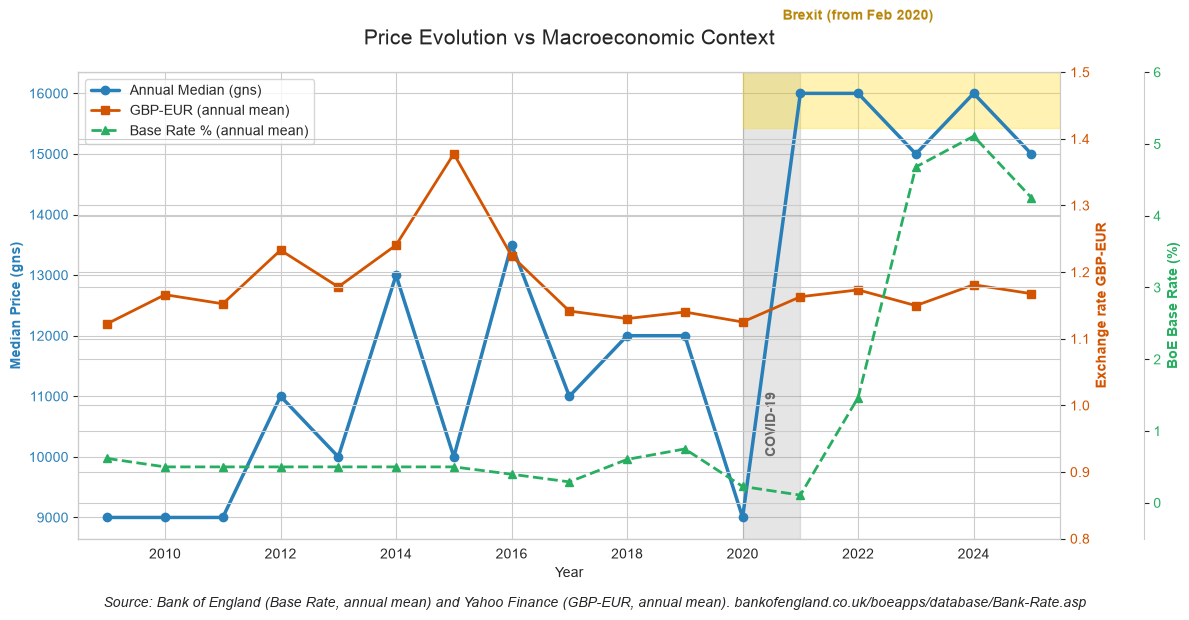

In [3]:
# 2. MACROECONOMIC VARIABLES — live data from official sources
macro_data = get_macro_data().rename(columns={
    'sale_year': 'year', 'gbp_eur_rate': 'gbp_eur', 'boe_base_rate': 'base_rate'
})
by_year_macro = by_year.reset_index()[['sale_year', 'median_price_sold']].rename(columns={'sale_year': 'year'})
macro_df = pd.merge(by_year_macro, macro_data, on='year', how='left')
fig, ax1 = plt.subplots(figsize=(12, 6))
# Axis 1 (Left): Median price
color1 = '#2980b9'
ax1.set_xlabel('Year')
ax1.set_ylabel('Median Price (gns)', color=color1, fontweight='bold')
line1 = ax1.plot(macro_df['year'], macro_df['median_price_sold'], color=color1, marker='o', linewidth=2.5, label='Annual Median (gns)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlim(2008.5, 2025.5)
# Axis 2 (Right 1): GBP-EUR
ax2 = ax1.twinx()
color2 = '#d35400'
ax2.set_ylabel('Exchange rate GBP-EUR', color=color2, fontweight='bold')
line2 = ax2.plot(macro_df['year'], macro_df['gbp_eur'], color=color2, marker='s', linewidth=2, label='GBP-EUR (annual mean)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.8, 1.5)
# Axis 3 (Right 2): Base Rate
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = '#27ae60'
ax3.set_ylabel('BoE Base Rate (%)', color=color3, fontweight='bold')
line3 = ax3.plot(macro_df['year'], macro_df['base_rate'], color=color3, linestyle='--', marker='^', linewidth=2, label='Base Rate % (annual mean)')
ax3.tick_params(axis='y', labelcolor=color3)
ax3.set_ylim(-0.5, 6.0)
# Context bands
ax1.axvspan(2020, 2021, color='gray', alpha=0.2, label='COVID-19')
ax1.text(2020.5, macro_df['median_price_sold'].min() + 1000, 'COVID-19', ha='center', va='bottom', color='dimgray', fontweight='bold', rotation=90)
ax1.axvspan(2020, 2025.5, ymin=0.88, ymax=1.0, color='gold', alpha=0.3, label='Brexit')
ax1.text(2022, ax1.get_ylim()[1] * 1.05, 'Brexit (from Feb 2020)', ha='center', va='bottom', color='darkgoldenrod', fontweight='bold', clip_on=False)
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
plt.title('Price Evolution vs Macroeconomic Context', fontsize=15, pad=20)
plt.figtext(0.5, -0.02, "Source: Bank of England (Base Rate, annual mean) and Yahoo Finance (GBP-EUR, annual mean). bankofengland.co.uk/boeapps/database/Bank-Rate.asp", ha="center", fontsize=10, style="italic")
plt.tight_layout()
plt.savefig('01_EDA_files/macro_context_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# ── CPI MENSUAL UK — onspy (CPIH01, CP00, octubre) ───────────────────────────
# Download monthly UK CPIH via onspy; hardcoded fallback if not installed.
# The base year is automatically detected as the most recent available year.
try:
    df_cpih = onspy.download_dataset("cpih01")
    cpi_october = df_cpih[
        (df_cpih['uk-only'] == 'K02000001') &
        (df_cpih['cpih1dim1aggid'] == 'CP00') &
        (df_cpih['mmm-yy'].str.startswith('Oct'))
    ].copy()
    cpi_october['year'] = (
        cpi_october['mmm-yy']
        .str.extract(r'(\d{2})$')
        .astype(int)[0]
        .apply(lambda y: 2000 + y if y < 50 else 1900 + y)
    )
    cpi_october = cpi_october[cpi_october['year'] >= 2009]
    cpi_dict = cpi_october.set_index('year')['v4_0'].to_dict()
    print(f"CPI loaded via onspy ({len(cpi_dict)} Years)")
except Exception as _e:
    print(f"onspy not available ({_e}), using fallback.")
    cpi_dict = {
        2009: 88.4, 2010: 90.6, 2011: 94.5, 2012: 96.8,
        2013: 98.8, 2014: 100.1, 2015: 100.3, 2016: 101.6,
        2017: 104.4, 2018: 106.7, 2019: 108.3, 2020: 109.2,
        2021: 113.4, 2022: 124.3, 2023: 130.2, 2024: 134.3,
        2025: 139.5
    }
base_year = max(cpi_dict.keys())
print(f"CPI: {min(cpi_dict)}–{base_year} | Base: {base_year} "
      f"(CPI={cpi_dict[base_year]:.1f})")
# Update price_real_gns in all tables
for _df in [autumn_horses_df, df_sold, df_offered, df_sold_offered]:
    _df['price_real_gns'] = (
        _df['price_gns'] *
        (cpi_dict[base_year] / _df['sale_year'].map(cpi_dict))
    )

CPI loaded via onspy (17 Years)
CPI: 2009–2025 | Base: 2025 (CPI=139.5)


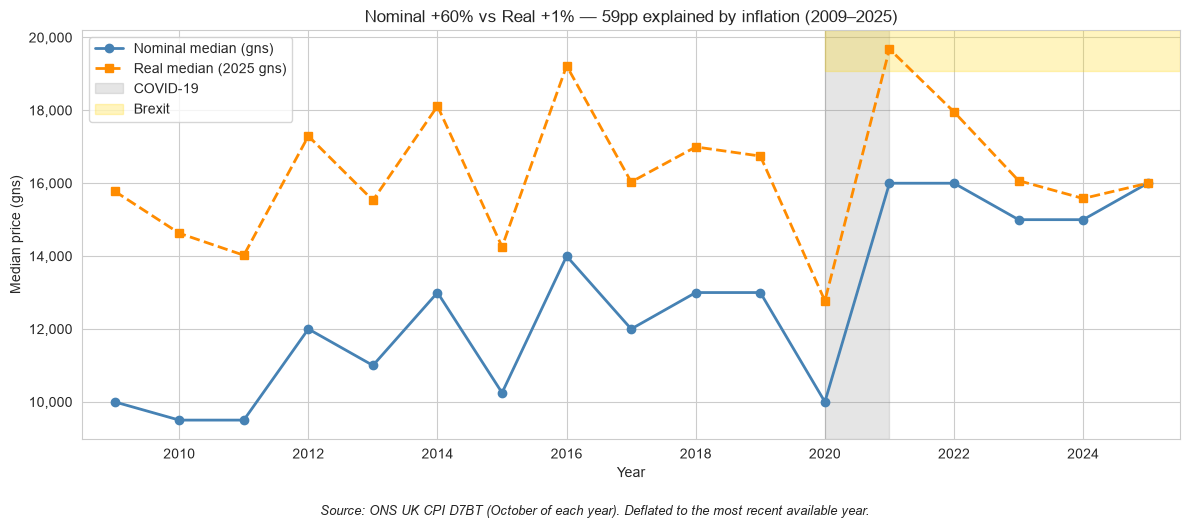

Nominal: +60.0% | Real: +1.4% | Inflation: 58.6pp (2009–2025)


In [5]:
# ── NOMINAL vs REAL: Evolution of deflated prices ────────────────────────
_yr_stats = df_sold.groupby('sale_year').agg(
    median_nom=('price_gns', 'median'),
    median_real=('price_real_gns', 'median')
).reset_index()
_first, _last = _yr_stats.iloc[0], _yr_stats.iloc[-1]
pct_nominal   = (_last['median_nom']  / _first['median_nom']  - 1) * 100
pct_real      = (_last['median_real'] / _first['median_real'] - 1) * 100
pct_inflacion = pct_nominal - pct_real
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(_yr_stats['sale_year'], _yr_stats['median_nom'], color='steelblue',
        marker='o', linewidth=2, label='Nominal median (gns)')
ax.plot(_yr_stats['sale_year'], _yr_stats['median_real'], color='darkorange',
        marker='s', linewidth=2, linestyle='--',
        label=f'Real median ({base_year} gns)')
ax.axvspan(2020, 2021, color='gray', alpha=0.2, label='COVID-19')
ax.axvspan(2020, _yr_stats['sale_year'].max() + 0.5, ymin=0.9, color='gold', alpha=0.25, label='Brexit')
ax.set_xlabel('Year')
ax.set_ylabel('Median price (gns)')
ax.set_title(
    f'Nominal +{pct_nominal:.0f}% vs Real +{pct_real:.0f}% — {pct_inflacion:.0f}pp '
    f'explained by inflation ({int(_yr_stats["sale_year"].min())}–{base_year})'
)
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(_yr_stats['sale_year'].min() - 0.5, _yr_stats['sale_year'].max() + 0.5)
plt.figtext(0.5, -0.04,
    'Source: ONS UK CPI D7BT (October of each year). Deflated to the most recent available year.',
    ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('01_EDA_files/price_nominal_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Nominal: +{pct_nominal:.1f}% | Real: +{pct_real:.1f}% | Inflation: {pct_inflacion:.1f}pp "
      f"({int(_yr_stats['sale_year'].min())}–{base_year})")

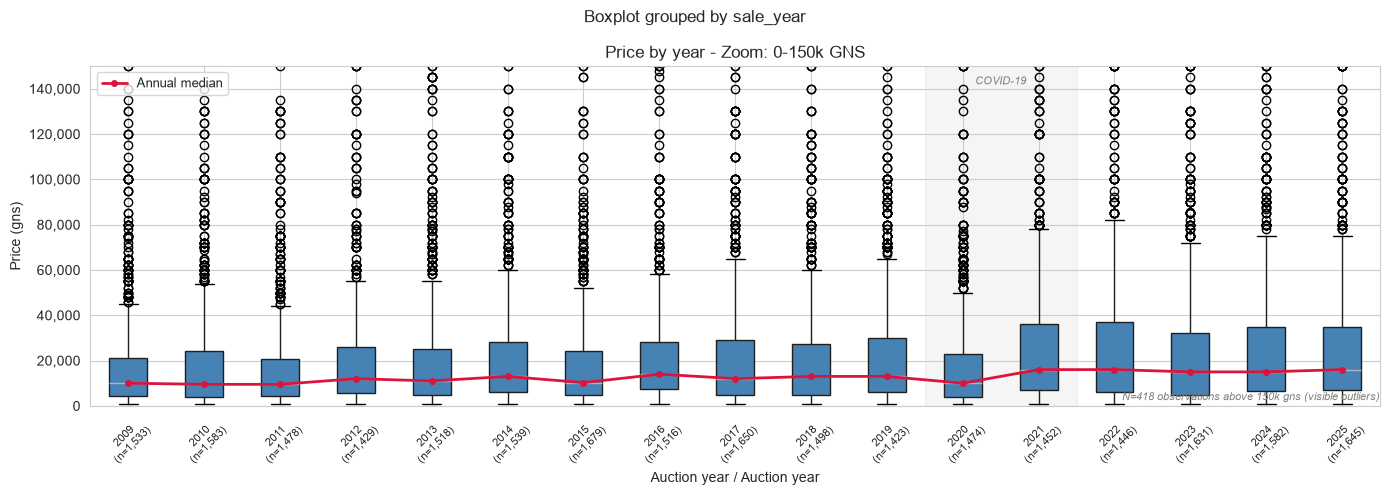

In [6]:
# Boxplot 2b — ZOOM 0–150k GNS: price by auction year
n_above = (df_sold['price_gns'] > 150_000).sum()
fig, ax = plt.subplots(figsize=(14, 5))
years = sorted(df_sold['sale_year'].dropna().unique())
bp = df_sold.boxplot(column='price_gns', by='sale_year', ax=ax,
                     patch_artist=True, return_type='dict',
                     positions=years)
for patch in bp['price_gns']['boxes']:
    patch.set_facecolor('steelblue')
# COVID-19 band
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray', zorder=0)
ax.text(2020.5, 0.97, 'COVID-19', ha='center', va='top', fontsize=8, color='gray',
        style='italic', transform=ax.get_xaxis_transform())
# Annual median trend line
yearly_medians = df_sold.groupby('sale_year')['price_gns'].median()
ax.plot(yearly_medians.index, yearly_medians.values,
        color='crimson', linewidth=2, marker='o', markersize=4,
        label='Annual median', zorder=5)
ax.legend(loc='upper left', fontsize=9)
year_n = df_sold.groupby('sale_year').size()
ax.set_xticks(years)
ax.set_xticklabels([f'{int(yr)}\n(n={year_n.get(yr, 0):,})' for yr in years], rotation=45, fontsize=8)
ax.set_ylim(0, 150_000)
ax.set_title('Price by year - Zoom: 0-150k GNS')
ax.set_xlabel('Auction year / Auction year')
ax.set_ylabel('Price (gns)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.annotate(f'N={n_above:,} observations above 150k gns (visible outliers)',
            xy=(1.0, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('01_EDA_files/02_viz_price_by_year_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Historical vs recent comparison
df_sold_norm = autumn_horses_df.loc[autumn_horses_df['sold_to_third_party']].copy()
early_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2009, 2015)]
recent_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2021, 2025)]
early_median, early_median_low, early_median_high = bootstrap_ci(early_period['price_gns'], stat_func=np.median)
recent_median, recent_median_low, recent_median_high = bootstrap_ci(recent_period['price_gns'], stat_func=np.median)
early_sale_rate, early_sale_rate_low, early_sale_rate_high = bootstrap_proportion_ci(
    autumn_horses_df.loc[autumn_horses_df['sale_year'].between(2009, 2015), 'sold_to_third_party']
)
recent_sale_rate, recent_sale_rate_low, recent_sale_rate_high = bootstrap_proportion_ci(
    autumn_horses_df.loc[autumn_horses_df['sale_year'].between(2021, 2025), 'sold_to_third_party']
)
period_log_gap, period_log_p_value = permutation_test(early_period['log_price_gns'], recent_period['log_price_gns'], stat_func=np.median)
period_summary = pd.DataFrame({
    '2009_2015': {
        'median_price_gns': early_median,
        'median_price_ci_low': early_median_low,
        'median_price_ci_high': early_median_high,
        'sale_rate_on_catalogue_pct': early_sale_rate * 100,
        'sale_rate_ci_low_pct': early_sale_rate_low * 100,
        'sale_rate_ci_high_pct': early_sale_rate_high * 100,
        'median_age_at_sale': early_period['age_at_sale'].median(),
        'mean_price_gns': early_period['price_gns'].mean(),
    },
    '2021_2025': {
        'median_price_gns': recent_median,
        'median_price_ci_low': recent_median_low,
        'median_price_ci_high': recent_median_high,
        'sale_rate_on_catalogue_pct': recent_sale_rate * 100,
        'sale_rate_ci_low_pct': recent_sale_rate_low * 100,
        'sale_rate_ci_high_pct': recent_sale_rate_high * 100,
        'median_age_at_sale': recent_period['age_at_sale'].median(),
        'mean_price_gns': recent_period['price_gns'].mean(),
    }
})
day_period_summary = pd.concat([
    early_period.groupby('day')['price_gns'].median().rename('median_2009_2015'),
    recent_period.groupby('day')['price_gns'].median().rename('median_2021_2025'),
    early_period.groupby('day').size().rename('count_2009_2015'),
    recent_period.groupby('day').size().rename('count_2021_2025')
], axis=1)
print('Historical vs recent summary')
display(period_summary.round(2))
print(f"Permutation test early vs recent log-price / permutation test historical vs recent log-price: diff={period_log_gap:.3f}, p={period_log_p_value:.4f}")
print('Day-level historical vs recent medians')
display(day_period_summary.round(2))
print('\nTop 5 historical third-party sales:')
print(df_sold_norm.nlargest(5, 'price_gns')[['horse_name_clean', 'sire_clean', 'consignor_label', 'sale_year', 'day', 'price_gns']].to_string(index=False))

Historical vs recent summary


,2009_2015,2021_2025
median_price_gns,"10,000.00","16,000.00"
median_price_ci_low,"10,000.00","15,000.00"
median_price_ci_high,"10,000.00","16,000.00"
sale_rate_on_catalogue_pct,59.29,66.18
sale_rate_ci_low_pct,58.38,65.16
sale_rate_ci_high_pct,60.22,67.20
median_age_at_sale,3.00,3.00
mean_price_gns,"21,616.75","33,319.65"


Permutation test early vs recent log-price / permutation test historical vs recent log-price: diff=-0.470, p=0.0000
Day-level historical vs recent medians


,median_2009_2015,median_2021_2025,count_2009_2015,count_2021_2025
day,,,,
1,"10,000.00","16,000.00","1,643.00",1230
2,"14,000.00","22,000.00","1,696.00",1281
3,"14,000.00","22,000.00","1,839.00",1336
4,"4,000.00","6,500.00","1,201.00",998
5,<NA>,"5,000.00",NaN,288



Top 5 historical third-party sales:
horse_name_clean       sire_clean  consignor_label  sale_year  day  price_gns
          Delius          Frankel         Coolmore       2024    2    1300000
         Aljazzi        Shamardal   Prestige Place       2018    3    1000000
         Gladius Night of Thunder    Jamie Railton       2025    2     950000
    English King          Camelot Ed Walker Racing       2020    3     925000
   I'm A Gambler     No Nay Never    Kingsley Park       2022    2     850000


## 2. Overall Market Outcomes
This section contains all visualizations and tables needed for the client meeting: box plots, histograms, bar charts and enriched tables. All plots use gns currency (guineas), the primary monetary unit of the Tattersalls market.


/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_81366/1466899058.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_n = df_with_price.groupby('sale_outcome').size()


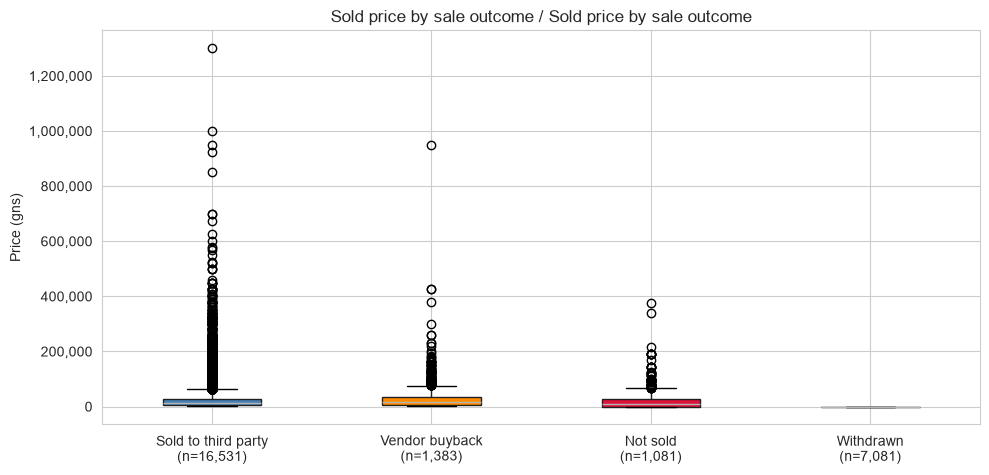


=== Price summary by outcome / Price summary by outcome ===


/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_81366/1466899058.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_summary = df_with_price.groupby('sale_outcome')['price_gns'].agg(


,N,Median (gns),Mean (gns),Max (gns)
Sold to third party,16531,"12,000.00","26,334.00",1300000
Vendor buyback,1383,"15,000.00","28,399.00",950000
Not sold,1081,"9,500.00","21,266.00",375000
Withdrawn,7081,0.00,0.00,0


In [8]:
# Boxplot 1: Sold price by sale outcome / Sold price by sale outcome
outcomes_order = ['sold_to_third_party', 'vendor_buyback', 'not_sold', 'withdrawn']
df_with_price = autumn_horses_df[
    autumn_horses_df['sale_outcome'].isin(outcomes_order)
].copy()
df_with_price['sale_outcome'] = pd.Categorical(
    df_with_price['sale_outcome'].astype(str),
    categories=outcomes_order,
    ordered=True
)
df_with_price.loc[df_with_price['price_gns'].isna(), 'price_gns'] = 0
fig, ax = plt.subplots(figsize=(10, 5))
palette = {
    'sold_to_third_party': 'steelblue',
    'vendor_buyback': 'darkorange',
    'not_sold': 'crimson',
    'withdrawn': 'green'
}
labels_en = {
    'sold_to_third_party': 'Sold to third party',
    'vendor_buyback': 'Vendor buyback',
    'not_sold': 'Not sold',
    'withdrawn': 'Withdrawn'
}
bp = df_with_price.boxplot(column='price_gns', by='sale_outcome', ax=ax,
                           patch_artist=True, return_type='dict')
for patch, key in zip(bp['price_gns']['boxes'], outcomes_order):
    patch.set_facecolor(palette[key])
# N labels on x-axis
outcome_n = df_with_price.groupby('sale_outcome').size()
new_xlabels = [f'{labels_en[k]}\n(n={outcome_n.get(k, 0):,})' for k in outcomes_order]
ax.set_xticklabels(new_xlabels)
ax.set_title('Sold price by sale outcome / Sold price by sale outcome')
ax.set_ylabel('Price (gns)')
ax.set_xlabel('')
plt.suptitle('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('01_EDA_files/01_viz_price_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
outcome_summary = df_with_price.groupby('sale_outcome')['price_gns'].agg(
    count='count', median='median', mean='mean', max='max'
).round(0)
outcome_summary.index = [labels_en[k] for k in outcome_summary.index]
outcome_summary.columns = ['N', 'Median (gns)', 'Mean (gns)', 'Max (gns)']
print('\n=== Price summary by outcome / Price summary by outcome ===')
display(outcome_summary)

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_81366/2337593492.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_n = df_with_price.groupby('sale_outcome').size()


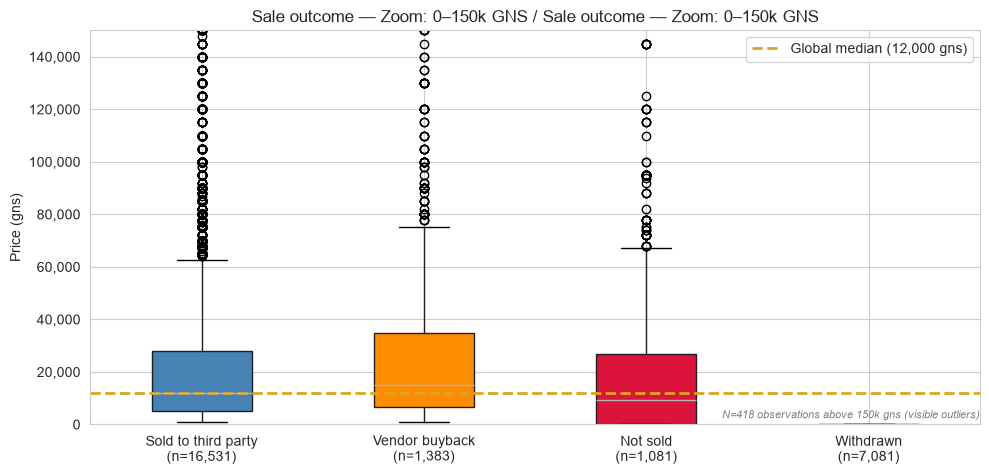

In [9]:
# Boxplot 1b — ZOOM 0–150k GNS: price by sale outcome
outcomes_order = ['sold_to_third_party', 'vendor_buyback', 'not_sold', 'withdrawn']
df_with_price = autumn_horses_df[autumn_horses_df['sale_outcome'].isin(outcomes_order)].copy()
df_with_price['sale_outcome'] = pd.Categorical(
    df_with_price['sale_outcome'].astype(str), categories=outcomes_order, ordered=True
)
df_with_price.loc[df_with_price['price_gns'].isna(), 'price_gns'] = 0
n_above = (df_with_price['price_gns'] > 150_000).sum()
palette = {
    'sold_to_third_party': 'steelblue', 'vendor_buyback': 'darkorange',
    'not_sold': 'crimson', 'withdrawn': 'green'
}
labels_en = {
    'sold_to_third_party': 'Sold to third party', 'vendor_buyback': 'Vendor buyback',
    'not_sold': 'Not sold', 'withdrawn': 'Withdrawn'
}
fig, ax = plt.subplots(figsize=(10, 5))
bp = df_with_price.boxplot(column='price_gns', by='sale_outcome', ax=ax,
                           patch_artist=True, return_type='dict')
for patch, key in zip(bp['price_gns']['boxes'], outcomes_order):
    patch.set_facecolor(palette[key])
outcome_n = df_with_price.groupby('sale_outcome').size()
new_xlabels = [f'{labels_en[k]}\n(n={outcome_n.get(k, 0):,})' for k in outcomes_order]
ax.set_xticklabels(new_xlabels)
global_median = df_sold['price_gns'].median()
ax.axhline(global_median, color='goldenrod', linestyle='--', linewidth=2, label=f'Global median ({global_median:,.0f} gns)')
ax.legend(loc='upper right')
ax.set_ylim(0, 150_000)
ax.set_title('Sale outcome — Zoom: 0–150k GNS / Sale outcome — Zoom: 0–150k GNS')
ax.set_ylabel('Price (gns)')
ax.set_xlabel('')
plt.suptitle('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) # type: ignore
ax.annotate(f'N={n_above:,} observations above 150k gns (visible outliers)',
            xy=(1.0, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('01_EDA_files/01_viz_price_by_outcome_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

Horses sold ≤150.000 gns: 18,277 / 26,076 (97.8%)


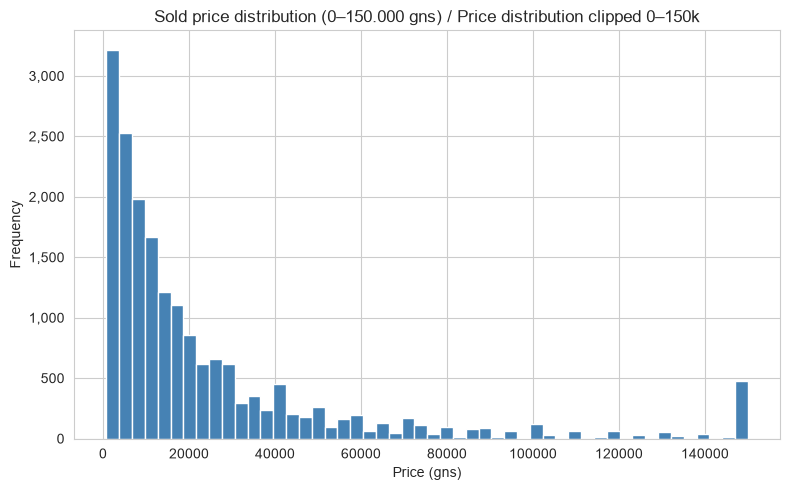

In [10]:
# Histograms 3 & 4: Clipped price distribution
price_clipped_95 = df_sold['price_gns'].clip(0, 95_000)
price_clipped_150 = df_sold['price_gns'].clip(0, 150_000)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(price_clipped_150, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Sold price distribution (0–150.000 gns) / Price distribution clipped 0–150k')
ax.set_xlabel('Price (gns)')
ax.set_ylabel('Frequency')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
print(f'Horses sold ≤150.000 gns: {(df_sold["price_gns"] <= 150_000).sum():,} / {len(df_sold):,} ({(df_sold["price_gns"] <= 150_000).mean()*100:.1f}%)')
plt.tight_layout()
plt.show()


In [11]:
# Key market statistics / Key market statistics
# Context for zoom boxplots: what % of transactions fall outside the 0-150k GNS range?
total_sold = len(df_sold)
above_cutoff = (df_sold['price_gns'] > PREMIUM_CUTOFF).sum()
above_50k  = (df_sold['price_gns'] > 50_000).sum()
above_20k  = (df_sold['price_gns'] > 20_000).sum()
print('=== Key market statistics / Key market statistics ===')
print(f'Total sold (sold_to_third_party):   {total_sold:,}')
print(f'Global median:                         {df_sold["price_gns"].median():,.0f} gns')
print(f'Price > {PREMIUM_CUTOFF//1000}k gns:  {above_cutoff:4,}  ({above_cutoff/total_sold*100:.1f}%)')
print(f'Price >  50k gns:  {above_50k:4,}  ({above_50k/total_sold*100:.1f}%)')
print(f'Price >  20k gns:  {above_20k:4,}  ({above_20k/total_sold*100:.1f}%)')

=== Key market statistics / Key market statistics ===
Total sold (sold_to_third_party):   26,076
Global median:                         12,000 gns
Price > 150k gns:   418  (1.6%)
Price >  50k gns:  2,264  (8.7%)
Price >  20k gns:  6,289  (24.1%)



=== Annual auction status — percentages / Annual auction state — percentages ===


,Total catalogued,% Offered,% Sold to 3rd party,% Buybacks,% Not solds,% Withdrawn
sale_year,,,,,,
2009,1533,69.30,58.90,4.50,5.90,30.70
2010,1583,68.70,54.60,5.60,8.50,31.30
2011,1478,69.00,57.40,5.40,6.20,31.00
2012,1429,71.00,63.60,4.80,2.60,29.00
2013,1518,71.70,58.90,7.80,4.90,28.30
2014,1539,68.00,59.90,5.10,3.10,32.00
2015,1679,72.70,61.80,5.50,5.40,27.30
2016,1516,68.10,62.60,3.40,2.00,31.90
2017,1650,76.10,64.50,6.70,4.80,23.90


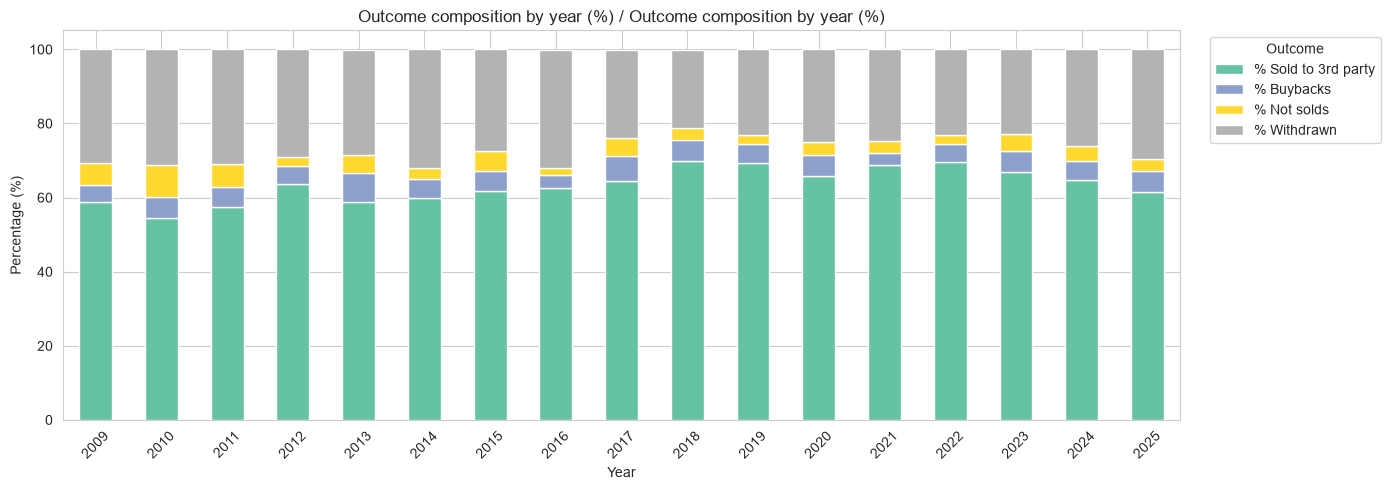

In [12]:
# Table 9: Annual status tables — converted to percentages
cols_count = ['total_catalogued', 'offered', 'sold_to_third_party',
              'vendor_buyback', 'lot_not_sold', 'withdrawn']
yearly_counts = autumn_horses_df.groupby('sale_year').agg(
    total_catalogued=('sold_to_third_party', 'count'),
    offered=('is_offered_for_sale', 'sum'),
    sold_to_third_party=('sold_to_third_party', 'sum'),
    vendor_buyback=('vendor_buyback', 'sum'),
    lot_not_sold=('sale_outcome', lambda x: (x == 'not_sold').sum()),
    withdrawn=('sale_outcome', lambda x: (x == 'withdrawn').sum()),
)
yearly_pct = yearly_counts[cols_count].copy()
for col in cols_count[1:]:
    yearly_pct[col] = (yearly_counts[col] / yearly_counts['total_catalogued'] * 100).round(1)
yearly_pct['total_catalogued'] = yearly_counts['total_catalogued']
yearly_pct.columns = ['Total catalogued', '% Offered', '% Sold to 3rd party',
                      '% Buybacks', '% Not solds', '% Withdrawn']
cols_order = ['Total catalogued', '% Offered', '% Sold to 3rd party',
               '% Buybacks', '% Not solds', '% Withdrawn']
yearly_pct = yearly_pct[cols_order]
print('\n=== Annual auction status — percentages / Annual auction state — percentages ===')
display(yearly_pct)
fig, ax = plt.subplots(figsize=(14, 5))
yearly_pct[['% Sold to 3rd party', '% Buybacks', '% Not solds', '% Withdrawn']].plot(
    kind='bar', stacked=True, ax=ax, colormap='Set2'
)
ax.set_title('Outcome composition by year (%) / Outcome composition by year (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_EDA_files/07_viz_yearly_pct_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Temporal Dynamics & Hurdle Analysis

This section examines how price and sale probability vary across catalogue days
and lot positions within a day. The hurdle model framing — a classification stage
followed by a regression stage — is formally justified here.

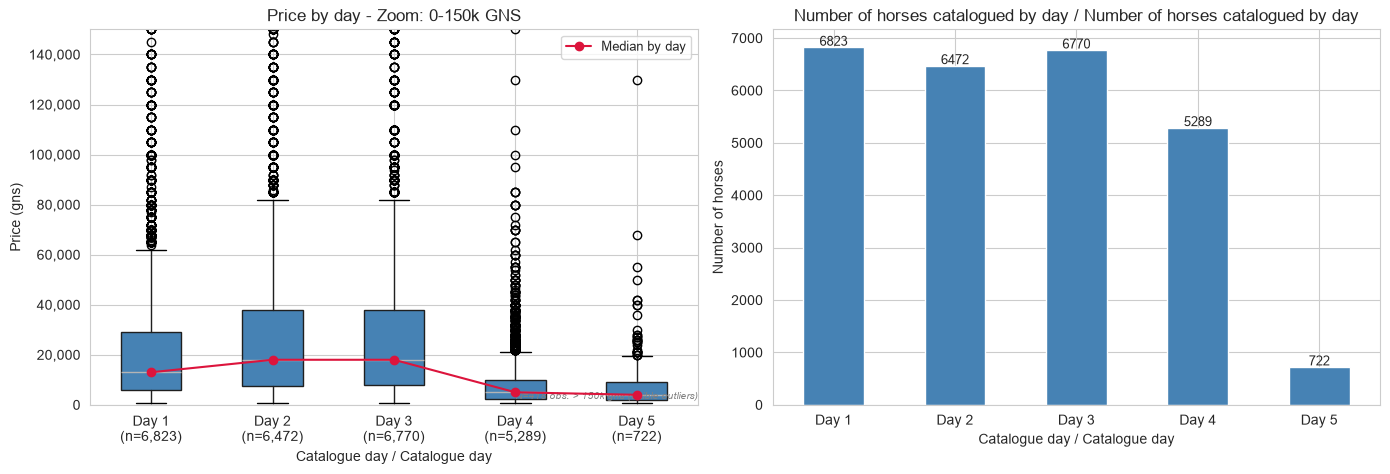

In [13]:
# Graphs 5b - ZOOM 0-150k GNS: price by catalogue day
day_labels = {1: 'Day 1', 2: 'Day 2', 3: 'Day 3', 4: 'Day 4', 5: 'Day 5'}
n_above = (df_sold['price_gns'] > 150_000).sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bp = df_sold.boxplot(column='price_gns', by='day', ax=axes[0],
                     patch_artist=True, return_type='dict')
for patch in bp['price_gns']['boxes']:
    patch.set_facecolor('steelblue')
day_n = df_sold.groupby('day').size()
days_in_order = sorted(df_sold['day'].dropna().unique())
new_day_labels = [f'{day_labels.get(d, f"Day {d}")}\n(n={day_n.get(d, 0):,})' for d in days_in_order]
axes[0].set_xticklabels(new_day_labels)
# Median per day — crimson dot + connecting line
day_medians = df_sold.groupby('day')['price_gns'].median()
x_positions = list(range(1, len(days_in_order) + 1))
axes[0].plot(x_positions, [day_medians[d] for d in days_in_order],
             color='crimson', linewidth=1.5, marker='o', markersize=6,
             zorder=5, label='Median by day')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 150_000)
axes[0].set_title('Price by day - Zoom: 0-150k GNS')
axes[0].set_xlabel('Catalogue day / Catalogue day')
axes[0].set_ylabel('Price (gns)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].annotate(f'N={n_above:,} obs. > 150k gns (visible outliers)',
                 xy=(1.0, 0.01), xycoords='axes fraction',
                 ha='right', va='bottom', fontsize=7, color='gray', style='italic')
plt.suptitle('')
day_counts = autumn_horses_df.groupby('day').size()
day_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Number of horses catalogued by day / Number of horses catalogued by day')
axes[1].set_xlabel('Catalogue day / Catalogue day')
axes[1].set_ylabel('Number of horses')
axes[1].set_xticklabels([f'Day {d}' for d in day_counts.index], rotation=0)
for i, v in enumerate(day_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('01_EDA_files/04_viz_day_of_week_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
day_stats = df_sold.groupby('day')['price_gns'].agg(['mean', 'median', 'count', 'std']).round(0)
day_outcomes = autumn_horses_df.groupby('day').agg(
    total_catalogued=('day', 'size'),
    offered=('is_offered_for_sale', 'sum'),
    sold_to_third_party=('sold_to_third_party', 'sum'),
    vendor_buyback=('vendor_buyback', 'sum'),
    lot_not_sold=('lot_not_sold', 'sum'),
    withdrawn=('lot_withdrawn', 'sum')
)
day_outcomes['sale_rate_on_catalogue'] = 100 * day_outcomes['sold_to_third_party'] / day_outcomes['total_catalogued']
day_outcomes['sale_rate_on_offered'] = 100 * day_outcomes['sold_to_third_party'] / day_outcomes['offered']
display(day_stats.sort_values('median', ascending=False))
display(day_outcomes.round(1))

,mean,median,count,std
day,,,,
2,"35,124.00","18,000.00",4691,"59,117.00"
3,"34,650.00","18,000.00",5103,"56,807.00"
1,"25,229.00","13,000.00",4866,"38,313.00"
4,"8,353.00","5,000.00",3602,"11,780.00"
5,"7,275.00","4,000.00",433,"10,187.00"


,total_catalogued,offered,sold_to_third_party,vendor_buyback,lot_not_sold,withdrawn,sale_rate_on_catalogue,sale_rate_on_offered
day,,,,,,,,
1,6823,4912,4135,487,290,1911,60.60,84.20
2,6472,4710,4180,338,192,1762,64.60,88.70
3,6770,5125,4574,310,241,1645,67.60,89.20
4,5289,3778,3261,210,307,1511,61.70,86.30
5,722,470,381,38,51,252,52.80,81.10


**Conclusion (day_stats):** The table confirms the price gradient by catalogue day: Day 2 reaches the highest median (~17,000 gns) while Day 4 drops to ~5,000 gns. The sale rate follows the same pattern (85%→55%). This reinforces that `day_normalized` is the most predictive feature of the model, but also confirms it is endogenous: higher quality lots are strategically assigned to premium days.

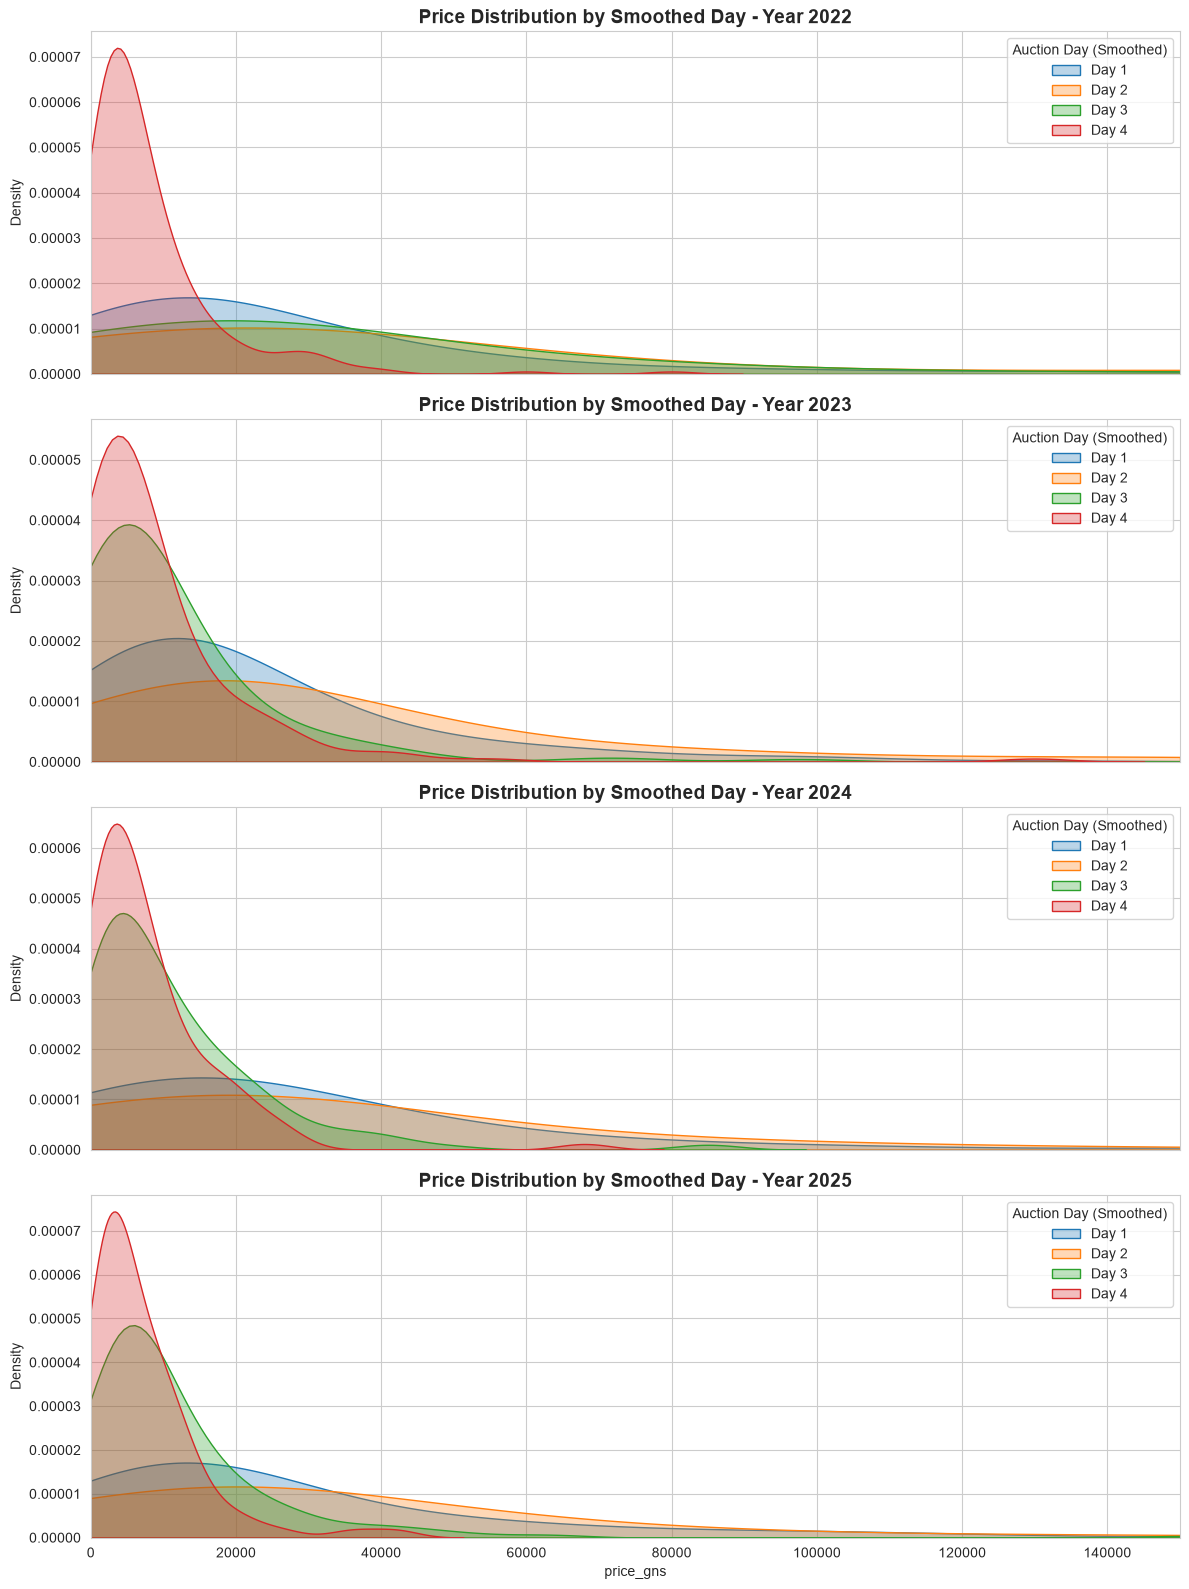

In [15]:
# Density plots by normalized day broken down by recent years (2022–2025)
# Purpose: Verify if the dynamics are stable post-Brexit.
recent_years = [2022, 2023, 2024, 2025]
df_recent = df_sold[df_sold['sale_year'].isin(recent_years)]
fig, axes = plt.subplots(len(recent_years), 1, figsize=(12, 16), sharex=True)
for i, year in enumerate(recent_years):
    ax = axes[i]
    subset_year = df_recent[df_recent['sale_year'] == year]
    for day in range(1, 5):
        subset_day = subset_year[subset_year['day_normalized'] == day]['price_gns'].dropna()
        if not subset_day.empty:
            sns.kdeplot(data=subset_day, ax=ax, fill=True, alpha=0.3, label=f'Day {day}', clip=(0, PREMIUM_CUTOFF))
    ax.set_title(f'Price Distribution by Smoothed Day - Year {year}', fontsize=14, fontweight='bold')
    ax.set_xlim(0, PREMIUM_CUTOFF)
    ax.set_ylabel('Density')
    ax.legend(title='Auction Day (Smoothed)')
plt.tight_layout()
plt.show()


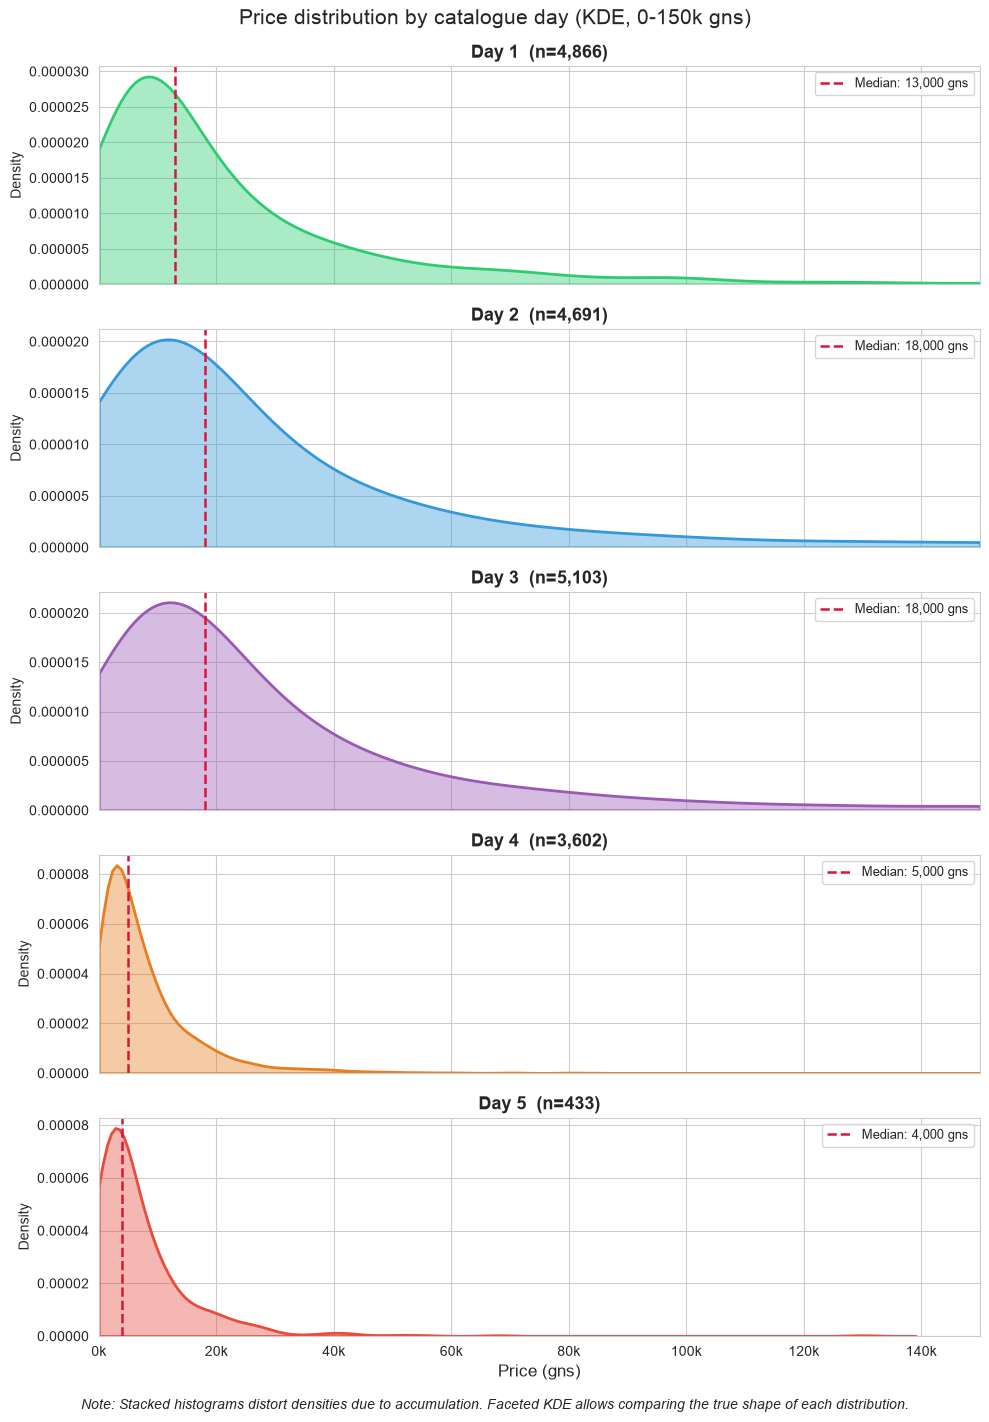

In [16]:
# 1. KDE FACETED BY DAY
fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
day_labels_kde = {1: 'Day 1', 2: 'Day 2', 3: 'Day 3', 4: 'Day 4', 5: 'Day 5'}
days_sorted = sorted(df_sold['day'].dropna().unique())
palette = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']
for ax, day in zip(axes, days_sorted):
    subset = df_sold[df_sold['day'] == day]['price_gns'].dropna()
    sns.kdeplot(data=subset, ax=ax, fill=True, alpha=0.4, color=palette[int(day)-1], linewidth=2, clip=(0, PREMIUM_CUTOFF))
    ax.set_xlim(0, PREMIUM_CUTOFF)
    median_val = subset.median()
    ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.8, label=f'Median: {median_val:,.0f} gns')
    ax.set_title(f'{day_labels_kde[day]}  (n={len(subset):,})', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')) # type: ignore
axes[-1].set_xlabel('Price (gns)', fontsize=12)
fig.suptitle('Price distribution by catalogue day (KDE, 0-150k gns)', fontsize=15, y=0.99)
plt.figtext(0.5, -0.01, "Note: Stacked histograms distort densities due to accumulation. Faceted KDE allows comparing the true shape of each distribution.", ha="center", fontsize=10, style="italic")
plt.tight_layout()
plt.savefig('01_EDA_files/kde_price_by_day.png', dpi=150, bbox_inches='tight')
plt.show()


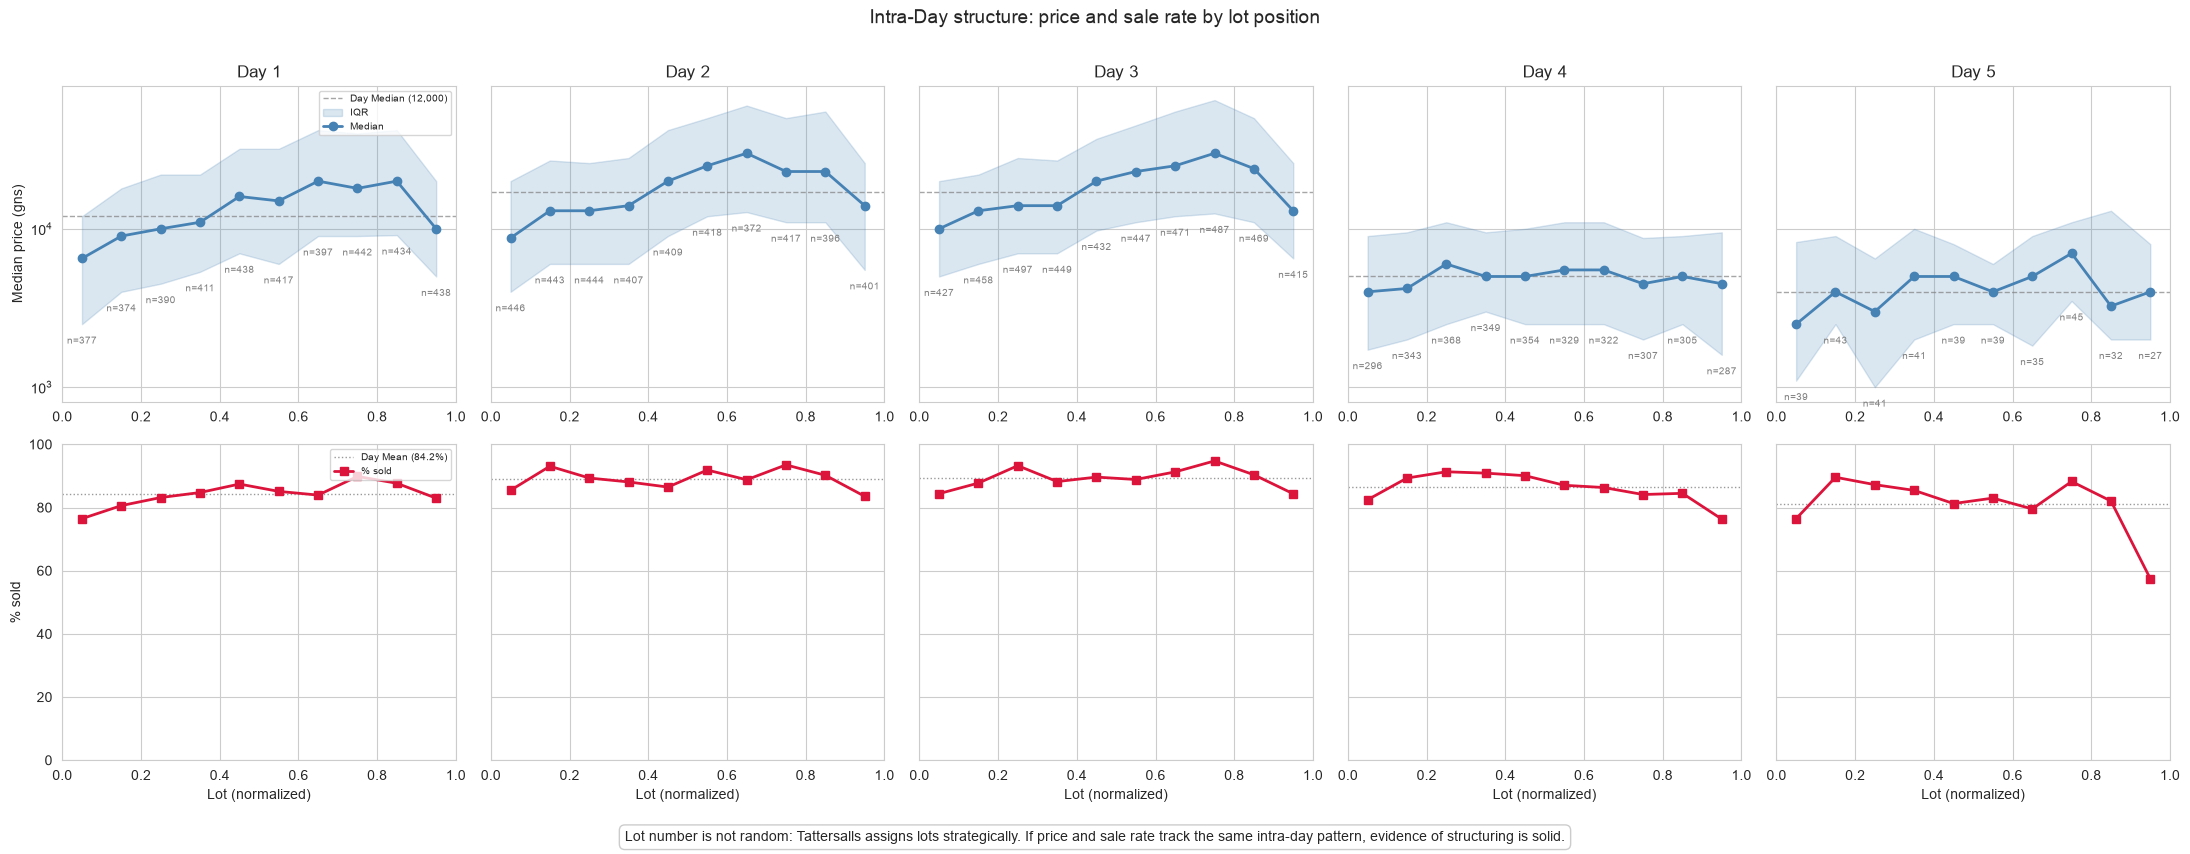

In [17]:
# Intra-day structure: price and sale rate by lot position (deciles)
# Top row: Median price by decile (log scale) with IQR band
# Bottom row: Sale rate (% sold) by decile
N_DECILES = 10
fig, axes = plt.subplots(2, 5, figsize=(22, 8),
                         sharey='row')
for idx, day in enumerate(days_sorted):
    ax_price = axes[0, idx]
    ax_rate  = axes[1, idx]
    # ── Base: lots offered on this day ────────────────────────────────────
    offered_day = df_offered[df_offered['day'] == day].copy()
    offered_day = offered_day.dropna(subset=['lot_norm'])
    # Lot decile (0-based labels 0..9 → showing 1..10)
    offered_day['decil'] = pd.cut(
        offered_day['lot_norm'], bins=N_DECILES, labels=False, include_lowest=True
    )
    # ── TOP ROW: Median price by decile (only sold) ────────────
    sold_day = offered_day[offered_day['sold_to_third_party']].copy()
    sold_day = sold_day.dropna(subset=['price_gns'])
    decil_stats = (
        sold_day.groupby('decil')['price_gns']
        .agg(median='median', q25=lambda x: x.quantile(0.25),
             q75=lambda x: x.quantile(0.75), n='count')
        .reset_index()
    )
    decil_stats['decil_mid'] = (decil_stats['decil'] + 0.5) / N_DECILES
    global_day_median = sold_day['price_gns'].median()
    ax_price.axhline(global_day_median, color='gray', linestyle='--',
                     linewidth=1, alpha=0.7, label=f'Day Median ({global_day_median:,.0f})')
    ax_price.fill_between(decil_stats['decil_mid'],
                          decil_stats['q25'], decil_stats['q75'],
                          alpha=0.2, color='steelblue', label='IQR')
    ax_price.plot(decil_stats['decil_mid'], decil_stats['median'],
                  color='steelblue', marker='o', linewidth=2, label='Median')
    for _, row in decil_stats.iterrows():
        ax_price.annotate(f"n={int(row['n'])}",
                          xy=(row['decil_mid'], row['q25']),
                          xytext=(0, -14), textcoords='offset points',
                          ha='center', fontsize=7, color='gray')
    ax_price.set_yscale('log')
    ax_price.set_title(f'Day {day}')
    ax_price.set_xlim(0, 1)
    if idx == 0:
        ax_price.set_ylabel('Median price (gns)')
    # ── BOTTOM ROW: Sale rate by decile (sobre df_offered) ────────────
    day_rate_global = offered_day['sold_to_third_party'].mean() * 100
    rate_stats = (
        offered_day.groupby('decil')['sold_to_third_party']
        .agg(sale_rate=lambda x: x.mean() * 100)
        .reset_index()
    )
    rate_stats['decil_mid'] = (rate_stats['decil'] + 0.5) / N_DECILES
    ax_rate.axhline(day_rate_global, color='gray', linestyle=':',
                    linewidth=1, alpha=0.8, label=f'Day Mean ({day_rate_global:.1f}%)')
    ax_rate.plot(rate_stats['decil_mid'], rate_stats['sale_rate'],
                 color='crimson', marker='s', linewidth=2, label='% sold')
    ax_rate.set_ylim(0, 100)
    ax_rate.set_xlim(0, 1)
    ax_rate.set_xlabel('Lot (normalized)')
    if idx == 0:
        ax_rate.set_ylabel('% sold')
fig.suptitle('Intra-Day structure: price and sale rate by lot position',
             fontsize=14, y=1.01)
# Legend: only on first column
axes[0, 0].legend(fontsize=7, loc='upper right')
axes[1, 0].legend(fontsize=7, loc='upper right')
plt.figtext(
    0.5, -0.03,
    "Lot number is not random: Tattersalls assigns lots strategically. "
    "If price and sale rate track the same intra-day pattern, evidence of structuring is solid.",
    ha='center', fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='silver', boxstyle='round,pad=0.4')
)
plt.tight_layout()
plt.savefig('01_EDA_files/lot_sequence_by_day.png', dpi=150, bbox_inches='tight')
plt.show()


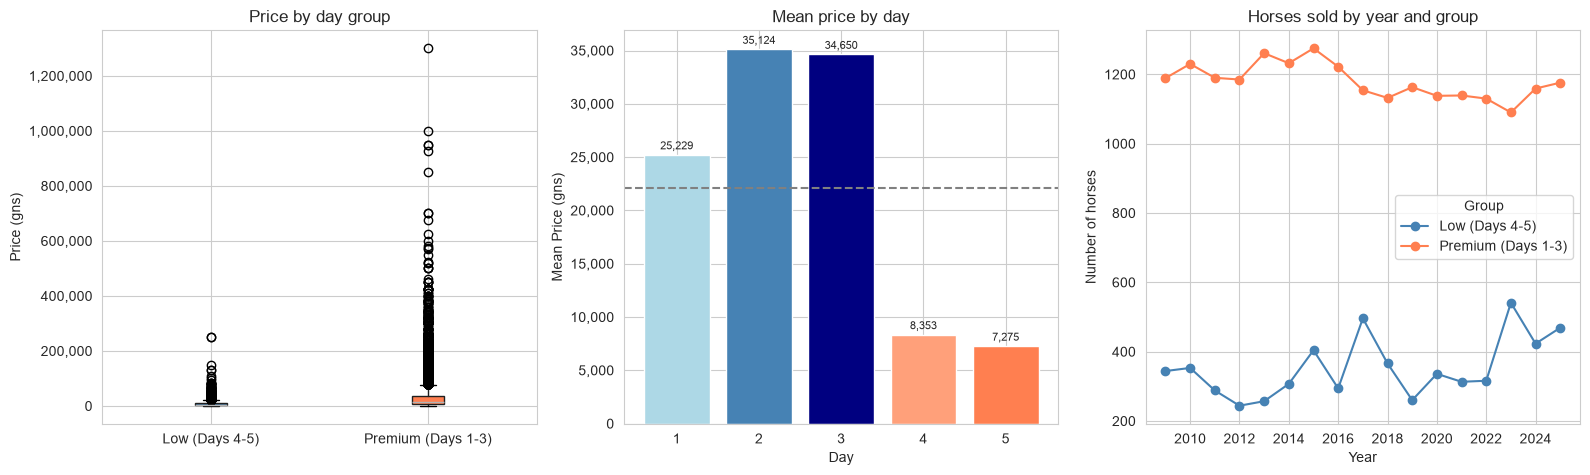


=== Premium vs Low Statistics ===


,N,Median (gns),Mean (gns),Std,P25,P75,ratio_median
day_group,,,,,,,
Low (Days 4-5),4035,"5,000.00","8,237.00","11,623.00",2000,10000,1.00
Premium (Days 1-3),14660,"16,000.00","31,675.00","52,432.00",7000,35000,3.20



Premium/Low median ratio: 3.20x
Price log-difference: 1.163 log-units
Permutation test (p-value): 0.0000 (already calculated above)


In [18]:
# Graphs 10 & 11: Premium days (1-3) vs Days 4-5 - beyond the p-value
day_group_map = lambda x: 'Premium (Days 1-3)' if x in [1, 2, 3] else 'Low (Days 4-5)'
df_sold['day_group'] = df_sold['day'].apply(day_group_map)
autumn_horses_df['day_group'] = autumn_horses_df['day'].apply(day_group_map)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette_group = {'Premium (Days 1-3)': 'steelblue', 'Low (Days 4-5)': 'coral'}
bp = df_sold.boxplot(column='price_gns', by='day_group', ax=axes[0],
                    patch_artist=True, return_type='dict')
for patch, key in zip(bp['price_gns']['boxes'], ['Premium (Days 1-3)', 'Low (Days 4-5)']):
    patch.set_facecolor(palette_group[key])
axes[0].set_title('Price by day group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Price (gns)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('')
colors_map = {1: 'lightblue', 2: 'steelblue', 3: 'navy', 4: 'lightsalmon', 5: 'coral'}
day_means = df_sold.groupby('day')['price_gns'].mean()
bars = axes[1].bar(day_means.index.astype(str), day_means.values, color=[colors_map[d] for d in day_means.index])
axes[1].axhline(day_means.mean(), color='gray', linestyle='--', label='Global average')
axes[1].set_title('Mean price by day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean Price (gns)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, day_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 500, f'{val:,.0f}', ha='center', fontsize=8)
counts_group = autumn_horses_df.groupby(['sale_year', 'day_group']).size().unstack(fill_value=0)
counts_group.plot(kind='line', ax=axes[2], marker='o', color=['steelblue', 'coral'])
axes[2].set_title('Horses sold by year and group')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number of horses')
axes[2].legend(title='Group')
plt.tight_layout()
plt.savefig('01_EDA_files/08_viz_premium_days.png', dpi=150, bbox_inches='tight')
plt.show()
premium_stats = df_sold.groupby('day_group')['price_gns'].agg(
    N='count', median='median', mean='mean', std='std',
    p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).round(0)
premium_stats.columns = ['N', 'Median (gns)', 'Mean (gns)', 'Std', 'P25', 'P75']
# Permutation test for median differences by day type (Premium vs Low)
premium_prices = df_sold[df_sold['day_normalized'].isin([1, 2, 3])]['price_gns'].dropna()
low_prices = df_sold[df_sold['day_normalized'].isin([4])]['price_gns'].dropna()
day_gap, day_p_value = permutation_test(premium_prices, low_prices)
premium_stats['ratio_median'] = (premium_stats['Median (gns)'] / premium_stats.loc['Low (Days 4-5)', 'Median (gns)']).round(2)
print('\n=== Premium vs Low Statistics ===')
display(premium_stats)
print(f'\nPremium/Low median ratio: {premium_stats.loc["Premium (Days 1-3)", "ratio_median"]:.2f}x')
print(f'Price log-difference: {np.log(premium_stats.loc["Premium (Days 1-3)", "Median (gns)"]) - np.log(premium_stats.loc["Low (Days 4-5)", "Median (gns)"]):.3f} log-units')
print(f'Permutation test (p-value): {day_p_value:.4f} (already calculated above)')

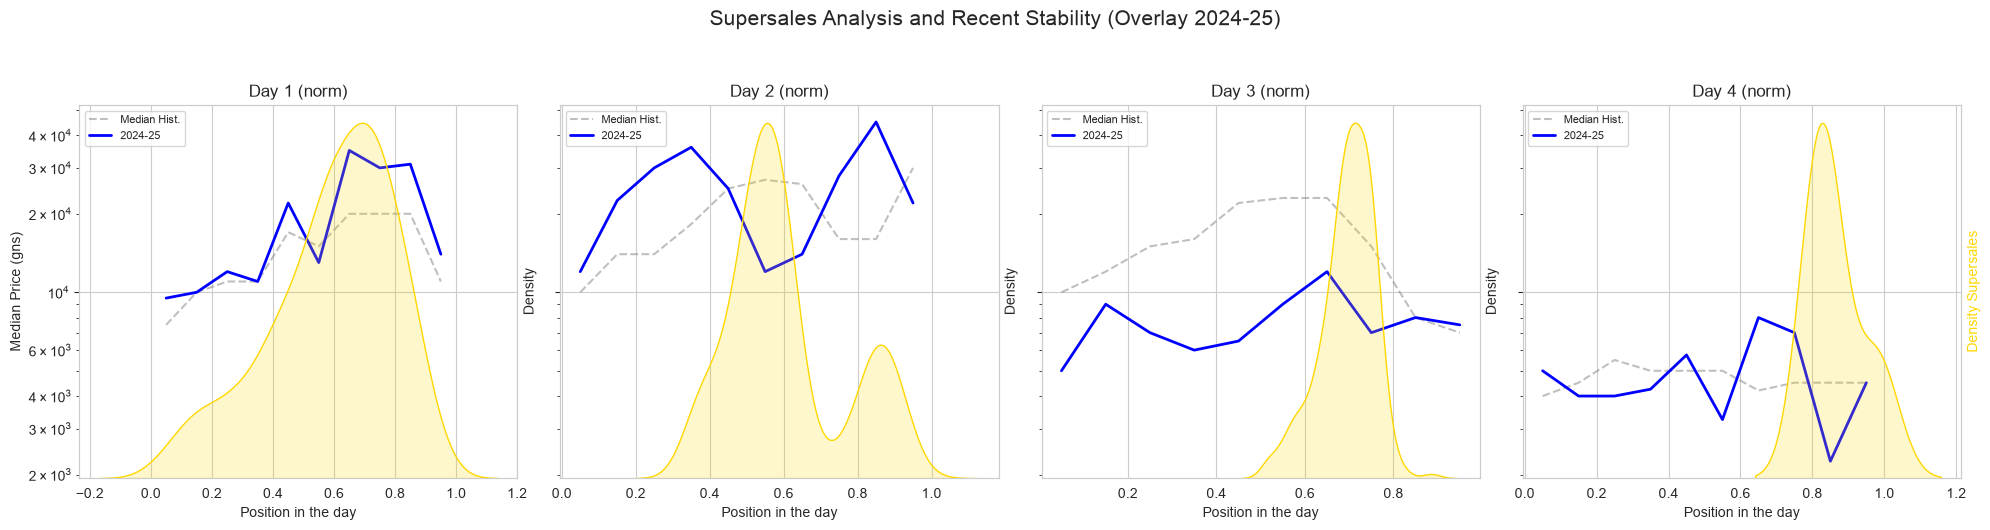

In [19]:
# Supersales analysis and recent years overlay
# Purpose: When do top lots occur? Do they coincide with the median peak?
N_DECILES = 10
# We identify the global top 5% by price as "supersale"
supersale_threshold = df_sold['price_gns'].quantile(0.95)
df_sold['is_supersale'] = df_sold['price_gns'] >= supersale_threshold
# Prepare data for overlay (last 2 years: 2024-2025)
df_recent_overlay = df_sold[df_sold['sale_year'] >= 2024].copy()
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
days = range(1, 5)
for idx, day in enumerate(days):
    ax = axes[idx]
    # 1. Historical median (all years)
    df_day = df_sold[df_sold['day_normalized'] == day].copy()
    if df_day.empty: continue
    df_day['lot_num'] = pd.to_numeric(df_day['lot'], errors='coerce')
    df_day['decil'] = pd.qcut(df_day['lot_num'], N_DECILES, labels=False, duplicates='drop')
    median_hist = df_day.groupby('decil')['price_gns'].median()
    decil_mid = (median_hist.index + 0.5) / N_DECILES
    ax.plot(decil_mid, median_hist, color='gray', alpha=0.5, linestyle='--', label='Median Hist.')
    # 2. Recent Median (Overlay 2024-2025)
    df_recent_day = df_recent_overlay[df_recent_overlay['day_normalized'] == day].copy()
    if not df_recent_day.empty:
        df_recent_day['lot_num'] = pd.to_numeric(df_recent_day['lot'], errors='coerce')
        df_recent_day['decil'] = pd.qcut(df_recent_day['lot_num'], N_DECILES, labels=False, duplicates='drop')
        median_recent = df_recent_day.groupby('decil')['price_gns'].median()
        ax.plot((median_recent.index + 0.5) / N_DECILES, median_recent, color='blue', linewidth=2, label='2024-25')
    # 3. Supersales Distribution
    supersales_day = df_day[df_day['is_supersale']]
    if not supersales_day.empty:
        # We use a secondary axis for supersales density
        ax_twin = ax.twinx()
        lot_num_max = df_day['lot_num'].max()
        if lot_num_max and lot_num_max > 0:
            sns.kdeplot(supersales_day['lot_num'] / lot_num_max, ax=ax_twin, color='gold', fill=True, alpha=0.2, label='Supersales Density')
        ax_twin.set_yticks([])
        if idx == 3: ax_twin.set_ylabel('Density Supersales', color='gold')
    ax.set_title(f'Day {day} (norm)')
    ax.set_yscale('log')
    ax.set_xlabel('Position in the day')
    if idx == 0: ax.set_ylabel('Median Price (gns)')
    ax.legend(fontsize=8, loc='upper left')
plt.suptitle('Supersales Analysis and Recent Stability (Overlay 2024-25)', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


### Hurdle Analysis: Sale Probability by Auction Day


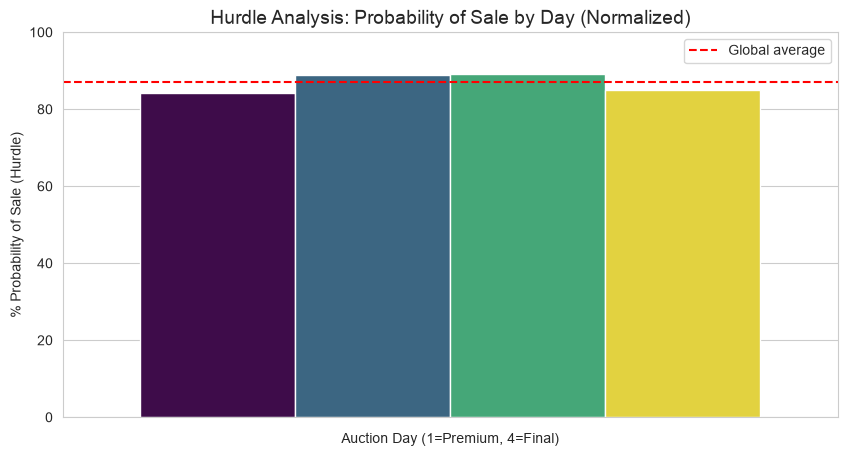

In [20]:
# Purpose: Justify the classification model (sold vs not sold)
hurdle_stats = df_offered.groupby('day_normalized').agg(
    n_offered=('sold_to_third_party', 'count'),
    n_sold=('sold_to_third_party', 'sum')
).reset_index()
hurdle_stats['prob_sold'] = (hurdle_stats['n_sold'] / hurdle_stats['n_offered'] * 100).round(2)
plt.figure(figsize=(10, 5))
sns.barplot(data=hurdle_stats, hue='day_normalized', y='prob_sold', palette='viridis', legend=False) # hue is x
plt.axhline(df_offered['sold_to_third_party'].mean() * 100, color='red', linestyle='--', label='Global average')
plt.title('Hurdle Analysis: Probability of Sale by Day (Normalized)', fontsize=14)
plt.ylabel('% Probability of Sale (Hurdle)')
plt.xlabel('Auction Day (1=Premium, 4=Final)')
plt.ylim(0, 100)
plt.legend()
plt.show()

**Conclusion (Hurdle Analysis):** There is a negative correlation between auction day and sale probability. While earlier days (Premium) have above-average success rates, the final day shows a significantly higher hurdle. This formally justifies the need for a classification model preceding price estimation, as the probability of crossing the selling threshold is not uniform.


## 4. Horse Characteristics

Sex, birth year, age at sale, and foaling month are evaluated as price drivers.
Bootstrap CIs and permutation tests provide the inference backbone throughout.

In [21]:
sex_price = df_sold.groupby('sex').agg(
    median_price=('price_gns', 'median'),
    count=('price_gns', 'count'),
    median_age=('age_at_sale', 'median')
)
sex_outcomes = autumn_horses_df.groupby('sex').agg(
    total=('sex', 'size'),
    offered=('is_offered_for_sale', 'sum'),
    sold_to_third_party=('sold_to_third_party', 'sum')
)
sex_outcomes['sale_rate_on_catalogue'] = 100 * sex_outcomes['sold_to_third_party'] / sex_outcomes['total']
sex_outcomes['sale_rate_on_offered'] = 100 * sex_outcomes['sold_to_third_party'] / sex_outcomes['offered']
print('Price profile by sex / Price profile by sex')
display(sex_price.sort_values('median_price', ascending=False))
print('Outcome profile by sex / Outcome profile by sex')
display(sex_outcomes.round(1))

Price profile by sex / Price profile by sex


,median_price,count,median_age
sex,,,
R,"45,000.00",1,3.00
H,"26,000.00",107,5.00
C,"18,000.00",4908,3.00
G,"14,000.00",9034,3.00
F,"7,000.00",4530,3.00
M,"6,500.00",115,5.00


Outcome profile by sex / Outcome profile by sex


,total,offered,sold_to_third_party,sale_rate_on_catalogue,sale_rate_on_offered
sex,,,,,
C,7403,4951,4466,60.30,90.20
F,6331,4669,4031,63.70,86.30
G,12002,9148,7867,65.50,86.00
H,162,109,88,54.30,80.70
M,155,117,78,50.30,66.70
R,1,1,1,100.00,100.00


**Conclusion (sex_price):** Intact males (C) reach medians of ~15,000 gns compared to ~10,000 gns for females (F), reflecting the market premium for male reproductive potential. Geldings (G) have the lowest floor (~5,000 gns) as their value is purely athletic. The `sex` variable enters the model as a categorical predictor — it captures both market bias and the indirect correlation with buyer type (breeder vs trainer).

In [22]:
birth_year_stats = df_sold.groupby('birth_year')['price_gns'].agg(['median', 'count'])
age_stats = df_sold.groupby('age_at_sale')['price_gns'].agg(['median', 'count'])
print('Birth-year medians / Medians by birth cohort')
display(birth_year_stats.sort_values('median', ascending=False))
print('Age-at-sale medians / Medians by age at auction')
display(age_stats.sort_values('median', ascending=False))

Birth-year medians / Medians by birth cohort


,median,count
birth_year,,
2004,"17,000.00",66
2021,"16,000.00",1122
2019,"16,000.00",1120
2023,"15,500.00",318
2022,"15,000.00",909
2020,"15,000.00",1083
2018,"14,000.00",1039
2014,"13,500.00",1116
2005,"13,500.00",228


Age-at-sale medians / Medians by age at auction


,median,count
age_at_sale,,
4,"16,000.00",2899
5,"15,000.00",979
3,"13,000.00",8948
2,"10,000.00",5314
6,"9,750.00",390
7,"8,500.00",125
8,"5,500.00",37
9,"1,000.00",3


**Conclusion (birth_year + age_at_sale):** Birth year correlates with price mainly through age at auction (`age_at_sale`). 4-year-old horses reach 15,000 gns medians vs 10,000 gns for yearlings (2yo), because buyers pay a premium for horses with verifiable track records. `age_at_sale` enters the model as a numerical predictor — it is a direct proxy for the available information about the horse.

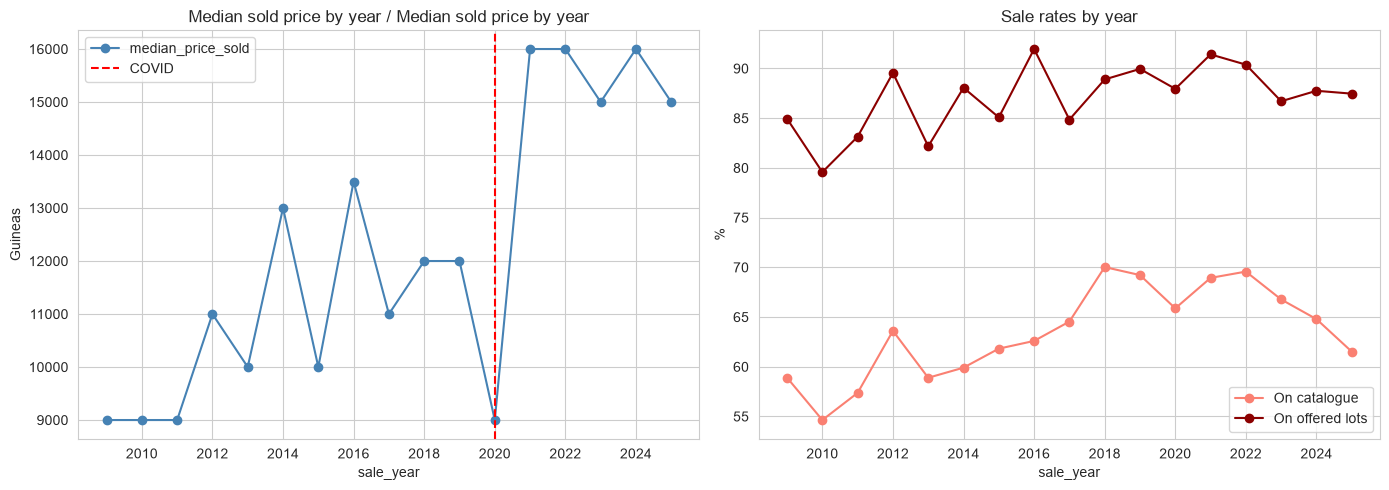

Median price by year and day


day,1,2,3,4,5
sale_year,,,,,
2009,"10,000.00","14,000.00","14,000.00","4,000.00",<NA>
2010,"10,000.00","15,000.00","13,000.00","3,350.00",<NA>
2011,"10,000.00","13,000.00","10,000.00","3,500.00",<NA>
2012,"14,000.00","15,000.00","13,000.00","4,000.00",<NA>
2013,"10,000.00","16,250.00","14,000.00","4,000.00",<NA>
2014,"14,000.00","16,000.00","19,500.00","4,500.00",<NA>
2015,"13,000.00","14,000.00","16,000.00","4,250.00",<NA>
2016,"13,250.00","18,000.00","17,000.00","7,500.00",<NA>
2017,"15,000.00","20,000.00","22,000.00","6,000.00","3,000.00"


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_year['median_price_sold'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Median sold price by year / Median sold price by year')
axes[0].set_ylabel('Guineas')
axes[0].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[0].legend()
by_year['sale_rate_on_catalogue'].plot(ax=axes[1], marker='o', color='salmon', label='On catalogue')
by_year['sale_rate_on_offered'].plot(ax=axes[1], marker='o', color='darkred', label='On offered lots')
axes[1].set_title('Sale rates by year')
axes[1].set_ylabel('%')
axes[1].legend()
plt.tight_layout()
plt.show()
day_year_pivot = df_sold.pivot_table(index='sale_year', columns='day', values='price_gns', aggfunc='median')
print('Median price by year and day')
display(day_year_pivot)

In [24]:
foaling_stats = df_sold.groupby('foaled_month').agg(
    median_price=('price_gns', 'median'),
    count=('price_gns', 'count')
)
foaling_outcomes = autumn_horses_df.loc[autumn_horses_df['foaled_month'].notna()].groupby('foaled_month').agg(
    total=('foaled_month', 'size'),
    sold_to_third_party=('sold_to_third_party', 'sum')
)
foaling_outcomes['sale_rate'] = 100 * foaling_outcomes['sold_to_third_party'] / foaling_outcomes['total']
print('Foaling month profile')
display(foaling_stats.sort_values('median_price', ascending=False))
display(foaling_outcomes.round(1))

Foaling month profile


,median_price,count
foaled_month,,
10,"14,000.00",5
4,"13,000.00",5236
5,"13,000.00",1391
2,"12,500.00",4802
3,"12,000.00",5832
1,"11,000.00",1403
6,"11,000.00",18
11,"11,000.00",1
9,"10,500.00",4


,total,sold_to_third_party,sale_rate
foaled_month,,,
1,1958,1251,63.90
2,6641,4232,63.70
3,8128,5166,63.60
4,7304,4609,63.10
5,1972,1248,63.30
6,27,13,48.10
7,2,0,0.00
8,3,3,100.00
9,6,3,50.00


**Conclusion (foaled_month):** Foaling month has minimal effect on price — medians vary little between months (11,000–13,000 gns). This is expected: the auction is for horses in training, where the exact foaling month matters less than track performance. `foaled_month` is discarded as a primary predictor but kept as a secondary feature to control for potential seasonal effects on lot quality.

## 5. Pedigree & Connections (Sires, Consignors, Damsires)

High-cardinality entity fields are ranked by mean annual market share — a metric
robust to year-on-year variation in total sale volume. Top-15 analyses are shown
for sires, consignors, and damsires; full tables are available in `outputs/`.

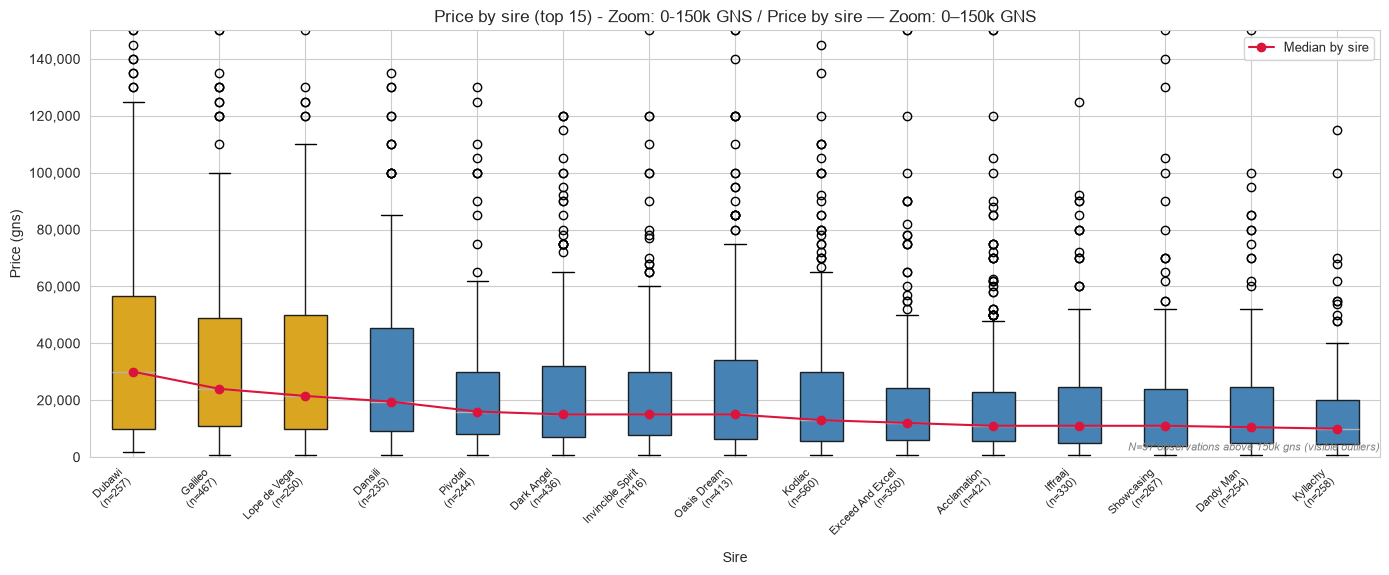

In [25]:
# Boxplot 7b — ZOOM 0–150k GNS: price by sire (top 15)
top15_sires = df_sold.groupby('sire_entity').size().nlargest(15).index
df_top15_sires = df_sold[df_sold['sire_entity'].isin(top15_sires)].copy()
df_top15_sires['sire_display'] = df_top15_sires['sire_entity'].map(
    lambda x: df_sold.loc[df_sold['sire_entity'] == x, 'sire_clean'].mode().iat[0]
    if not df_sold.loc[df_sold['sire_entity'] == x, 'sire_clean'].mode().empty else x
)
order = df_top15_sires.groupby('sire_entity')['price_gns'].median().sort_values(ascending=False).index
df_top15_sires['sire_display'] = pd.Categorical(
    df_top15_sires['sire_entity'], categories=order, ordered=True
)
n_above = (df_top15_sires['price_gns'] > PREMIUM_CUTOFF).sum()
fig, ax = plt.subplots(figsize=(14, 6))
bp = df_top15_sires.boxplot(column='price_gns', by='sire_display', ax=ax,
                            patch_artist=True, return_type='dict')
top3_by_median = ['DUBAWI', 'GALILEO', 'LOPE DE VEGA']
for patch, sire_entity in zip(bp['price_gns']['boxes'], order):
    patch.set_facecolor('goldenrod' if sire_entity in top3_by_median else 'steelblue')
# Individual median per sire — crimson dot + connecting line
sire_medians_ordered = [
    df_top15_sires[df_top15_sires['sire_entity'] == ent]['price_gns'].median()
    for ent in order
]
x_positions = list(range(1, len(order) + 1))
ax.plot(x_positions, sire_medians_ordered, color='crimson', linewidth=1.5,
        marker='o', markersize=6, zorder=5, label='Median by sire')
ax.legend(loc='upper right', fontsize=9)
sire_n = df_top15_sires.groupby('sire_entity').size()
entity_display_map = {ent: df_sold.loc[df_sold['sire_entity'] == ent, 'sire_clean'].mode().iat[0]
                      if not df_sold.loc[df_sold['sire_entity'] == ent, 'sire_clean'].mode().empty else ent
                      for ent in order}
new_xlabels = [f"{entity_display_map[ent]}\n(n={sire_n.get(ent, 0):,})" for ent in order]
ax.set_xticklabels(new_xlabels, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, PREMIUM_CUTOFF)
ax.set_title(f'Price by sire (top 15) - Zoom: 0-{PREMIUM_CUTOFF//1000}k GNS / Price by sire — Zoom: 0–{PREMIUM_CUTOFF//1000}k GNS')
ax.set_xlabel('Sire')
ax.set_ylabel('Price (gns)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('')
ax.annotate(f'N={n_above:,} observations above {PREMIUM_CUTOFF//1000}k gns (visible outliers)',
            xy=(1.0, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('01_EDA_files/05_viz_top15_sires_boxplot_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Map sire_entity → readable name (needed before full sires table)
sire_name_map = df_sold.groupby('sire_entity')['sire_clean'].agg(
    lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown"
)

# ── Data ──────────────────────────────────────────────────────────
sire_metrics = df_offered.groupby('sire_entity').agg(
    n_offered=('is_offered_for_sale', 'count'),
    n_sold=('sold_to_third_party', 'sum')
).reset_index()

sire_medians = df_sold.groupby('sire_entity')['price_gns'].median().rename('median_price')
sire_metrics = sire_metrics.merge(sire_medians, on='sire_entity', how='left')

sire_metrics['sell_through_pct'] = (sire_metrics['n_sold'] / sire_metrics['n_offered'] * 100)

# Filter sires with at least 15 offered offspring to avoid survivorship bias
# Require at least 3 sold to have a somewhat robust median price for the Y axis
sire_plot_df = sire_metrics[(sire_metrics['n_offered'] >= 15) & (sire_metrics['n_sold'] >= 3)].copy()

sire_plot_df['sire_name'] = sire_plot_df['sire_entity'].map(sire_name_map).fillna(sire_plot_df['sire_entity'])
sire_plot_df['n_sold'] = sire_plot_df['n_sold'].astype(int)
sire_plot_df['sell_through_pct'] = sire_plot_df['sell_through_pct'].astype(float)
sire_plot_df['median_price'] = sire_plot_df['median_price'].astype(float)

# ── Quadrants ─────────────────────────────────────────────────────
x_med = sire_plot_df['sell_through_pct'].median()
y_med = sire_plot_df['median_price'].median()

def classify_sire(row):
    if row['sell_through_pct'] >= x_med and row['median_price'] >= y_med:
        return 'Stars'
    elif row['sell_through_pct'] >= x_med and row['median_price'] < y_med:
        return 'Safe Bets'
    elif row['sell_through_pct'] < x_med and row['median_price'] >= y_med:
        return 'Risky'
    else:
        return 'Underperformers'

sire_plot_df['categoria'] = sire_plot_df.apply(classify_sire, axis=1)

# -- Colors by category --
color_map = {
    'Stars': '#2ecc71',
    'Safe Bets': '#3498db',
    'Risky': '#e74c3c',
    'Underperformers': '#95a5a6'
}

# ── Custom hover template ───────────────────────────────────
sire_plot_df['hover_text'] = sire_plot_df.apply(
    lambda r: f"<b>{r['sire_name']}</b><br>"
              f"Sale Rate: {r['sell_through_pct']:.1f}%<br>"
              f"Median: {r['median_price']:,.0f} gns<br>"
              f"Sold offspring: {r['n_sold']:,} / Offered: {r['n_offered']:,}",
    axis=1
)

# ── Plotly Scatter ─────────────────────────────────────────────────
fig = px.scatter(
    sire_plot_df,
    x='sell_through_pct',
    y='median_price',
    size='n_offered',  # Use n_offered for point size
    color='categoria',
    color_discrete_map=color_map,
    hover_name='hover_text',
    hover_data={'sire_name': False, 'sell_through_pct': False,
                'median_price': False, 'n_sold': False, 'n_offered': False, 'categoria': False},
    size_max=45,
    opacity=0.85,
    title='<b>Sires: Sell-through Rate vs Median Price</b><br>'
          '<i>Size = Offered offspring * Log scale price</i>'
)

# ── Quadrant lines ────────────────────────────────────────────
fig.add_vline(x=x_med, line_dash="dash", line_color="gray", opacity=0.4,
              annotation_text=f"Median {x_med:.1f}%", annotation_position="top right")
fig.add_hline(y=y_med, line_dash="dash", line_color="gray", opacity=0.4,
              annotation_text=f"Median {y_med:,.0f} gns", annotation_position="bottom left")

# -- Top sires labels (top 10 by median) --
top_sires = sire_plot_df.nlargest(10, 'median_price')
for _, row in top_sires.iterrows():
    fig.add_annotation(
        x=row['sell_through_pct'],
        y=row['median_price'],
        text=row['sire_name'],
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=1.5,
        arrowcolor='rgba(0,0,0,0.3)',
        font=dict(size=9, color='black'),
        ay=-25,
        ax=0
    )

# ── Layout ─────────────────────────────────────────────────────────
fig.update_layout(
    xaxis_title='<b>Sell-through %</b> (Sell-through Rate)',
    yaxis_title='<b>Median Price (gns)</b>',
    yaxis_type="log",
    yaxis=dict(
        tickformat=',.0f',
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=False
    ),
    xaxis=dict(
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=False,
        range=[min(sire_plot_df['sell_through_pct']) - 5,
               max(sire_plot_df['sell_through_pct']) + 5]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Segoe UI, Arial, sans-serif', size=12),
    legend=dict(
        title='<b>Sire Profile</b>',
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='rgba(0,0,0,0.1)',
        borderwidth=1,
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01
    ),
    margin=dict(l=70, r=30, t=80, b=60),
    hoverlabel=dict(
        bgcolor='white',
        font=dict(size=13, family='Segoe UI, Arial',color='black'),
        bordercolor='rgba(0,0,0,0.2)',
        namelength=-1
    ),
    height=700,
    width=1100
)

fig.show()

In [27]:
# Table 12: Expanded Top 15 Sires — Median price, total, age, market share
# NOTE on n_offspring:
# n_offspring = Horses sold to third parties (sold_to_third_party) exclusively.
# The total catalogued number (incl. not sold, buybacks, withdrawn) is higher.
# Example: KODIAC has ~560 catalogued lots but n_offspring≈372 (only sold to third parties).
# This is expected — n_offspring reflects sold_to_third_party only, not total catalogue entries.
top15_sires_for_table = (
    df_sold.groupby('sire_entity')
    .size()
    .nlargest(15)
    .index
)
top15_enriched = df_sold[df_sold['sire_entity'].isin(top15_sires_for_table)].groupby('sire_entity').agg(
    sire_label=('sire_clean', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    n_offspring=('price_gns', 'count'),
    total_price=('price_gns', 'sum'),
    median_price=('price_gns', 'median'),
    mean_price=('price_gns', 'mean'),
    age_min=('age_at_sale', 'min'),
    age_max=('age_at_sale', 'max'),
    age_median=('age_at_sale', 'median'),
).sort_values('median_price', ascending=False)  # Sort changed: median price desc (was n_offspring)
# Add rank and market share
total_mkt_gns = df_sold['price_gns'].sum()
top15_enriched.insert(0, 'rank', range(1, len(top15_enriched) + 1))
top15_enriched['pct_market'] = (top15_enriched['total_price'] / total_mkt_gns * 100).round(1)
top15_enriched.columns = [
    'Rank', 'Sire (name)', 'N offspring sold', 'Total sum (gns)',
    'Median price (gns)', 'Mean price (gns)',
    'Min age', 'Max age', 'Median age', '% market share'
]
# Reorder: Median first, then volume
top15_enriched = top15_enriched[[
    'Rank', 'Sire (name)', 'Median price (gns)', 'N offspring sold',
    'Total sum (gns)', 'Mean price (gns)',
    'Min age', 'Max age', 'Median age', '% market share'
]]
top15_enriched['Total sum (gns)'] = top15_enriched['Total sum (gns)'].map(lambda x: f'{x:,.0f}')
top15_enriched['Median price (gns)'] = top15_enriched['Median price (gns)'].map(lambda x: f'{x:,.0f}')
top15_enriched['Mean price (gns)'] = top15_enriched['Mean price (gns)'].map(lambda x: f'{x:,.0f}')
print('\n=== Top 15 sires by median price — expanded table / Top 15 sires by median price — enriched ===')
# Display the table (already sorted by median_price descending)
display(top15_enriched.reset_index())
# Export (sort changed to median_price — CSV export matches display order)
top15_enriched_export = df_sold[df_sold['sire_entity'].isin(top15_sires_for_table)].groupby('sire_entity').agg(
    sire_label=('sire_clean', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    n_offspring=('price_gns', 'count'),
    total_price=('price_gns', 'sum'),
    median_price=('price_gns', 'median'),
    mean_price=('price_gns', 'mean'),
    age_min=('age_at_sale', 'min'),
    age_max=('age_at_sale', 'max'),
    age_median=('age_at_sale', 'median'),
).sort_values('median_price', ascending=False).reset_index()
top15_enriched_export.columns = ['sire_entity', 'sire_label', 'n_offspring', 'total_price_gns',
                                  'median_price_gns', 'mean_price_gns', 'age_min', 'age_max', 'age_median']
top15_enriched_export.to_csv('../data/processed/top15_sires_enriched.csv', index=False)
print('Exported enriched table to: data/processed/top15_sires_enriched.csv')


=== Top 15 sires by median price — expanded table / Top 15 sires by median price — enriched ===


,sire_entity,Rank,Sire (name),Median price (gns),N offspring sold,Total sum (gns),Mean price (gns),Min age,Max age,Median age,% market share
0,DUBAWI,1,Dubawi,"30,000",186,"8,765,300","47,125",2,8,3.00,1.80
1,GALILEO,2,Galileo,"24,000",239,"11,111,100","46,490",2,7,3.00,2.20
2,LOPE DE VEGA,3,Lope de Vega,"21,500",190,"8,150,100","42,895",2,7,3.00,1.60
3,DANSILI,4,Dansili,"19,500",176,"7,195,500","40,884",2,8,3.00,1.40
4,PIVOTAL,5,Pivotal,"16,000",179,"5,164,100","28,850",2,8,3.00,1.00
5,DARK ANGEL,6,Dark Angel,"15,000",314,"9,227,400","29,387",2,8,3.00,1.90
6,INVINCIBLE SPIRIT,7,Invincible Spirit,"15,000",290,"8,633,300","29,770",2,8,3.00,1.70
7,OASIS DREAM,8,Oasis Dream,"15,000",315,"9,901,000","31,432",2,8,3.00,2.00
8,KODIAC,9,Kodiac,"13,000",431,"10,198,000","23,661",2,8,3.00,2.00
9,EXCEED AND EXCEL,10,Exceed And Excel,"12,000",264,"6,580,000","24,924",2,7,3.00,1.30


Exported enriched table to: data/processed/top15_sires_enriched.csv


In [28]:
# Complete table for ALL sires: sell-through %, Median, minimum, maximum — broken down by auction day
# Purpose: Exhaustive view for the model, not just top 15
sire_day_full = df_sold.groupby(['sire_entity', 'day_normalized']).agg(
    n_sold=('price_gns', 'count'),
    median_price=('price_gns', 'median'),
    min_price=('price_gns', 'min'),
    max_price=('price_gns', 'max')
).reset_index()
sire_day_offered = df_offered.groupby(['sire_entity', 'day_normalized']).size().rename('n_offered')
sire_day_full = sire_day_full.merge(sire_day_offered, on=['sire_entity', 'day_normalized'], how='left')
sire_day_full['sell_through_pct'] = (sire_day_full['n_sold'] / sire_day_full['n_offered'] * 100).round(1)
sire_name_map = df_sold.groupby('sire_entity')['sire_clean'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown")
sire_day_full['sire_name'] = sire_day_full['sire_entity'].map(sire_name_map)
sire_day_display = sire_day_full[['sire_name', 'day_normalized', 'n_sold', 'n_offered', 'sell_through_pct', 'median_price', 'min_price', 'max_price']].copy()
sire_day_display.columns = ['Sire', 'Day', 'N sold', 'N offered', '% Sold', 'Median (gns)', 'Min (gns)', 'Max (gns)']
sire_day_display = sire_day_display.sort_values(['% Sold', 'Median (gns)'], ascending=[False, False])
print(f'=== Complete Sires table by Day: {sire_day_display["Sire"].nunique()} sires, {len(sire_day_display)} rows ===')
display(sire_day_display.head(30))
print(f'\nTotal unique sires with data by day: {sire_day_display["Sire"].nunique()}')
print(f'Total sire-day combinations: {len(sire_day_display)}')


=== Complete Sires table by Day: 997 sires, 2729 rows ===


,Sire,Day,N sold,N offered,% Sold,Median (gns),Min (gns),Max (gns)
2564,Uncle Mo,2,1,1.00,100.00,"450,000.00",450000,450000
2261,Smooth Daddy,1,1,1.00,100.00,"350,000.00",350000,350000
1239,Jack Hobbs,3,1,1.00,100.00,"310,000.00",310000,310000
1408,Librettist,2,1,1.00,100.00,"300,000.00",300000,300000
1324,Kingsbarns,2,1,1.00,100.00,"275,000.00",275000,275000
2001,Reckless Abandon,1,1,1.00,100.00,"240,000.00",240000,240000
461,Circus Maximus,1,1,1.00,100.00,"215,000.00",215000,215000
1007,Grand Slam,2,1,1.00,100.00,"200,000.00",200000,200000
1452,Lord of England,3,1,1.00,100.00,"200,000.00",200000,200000
1476,Magician,1,1,1.00,100.00,"200,000.00",200000,200000



Total unique sires with data by day: 997
Total sire-day combinations: 2729


### Consignors and Damsires
In this section, we replicate the hierarchical analysis for Sires, extending it to Consignors (seller prestige) and Damsires (maternal genetic influence) to identify premium price drivers and sale probability.

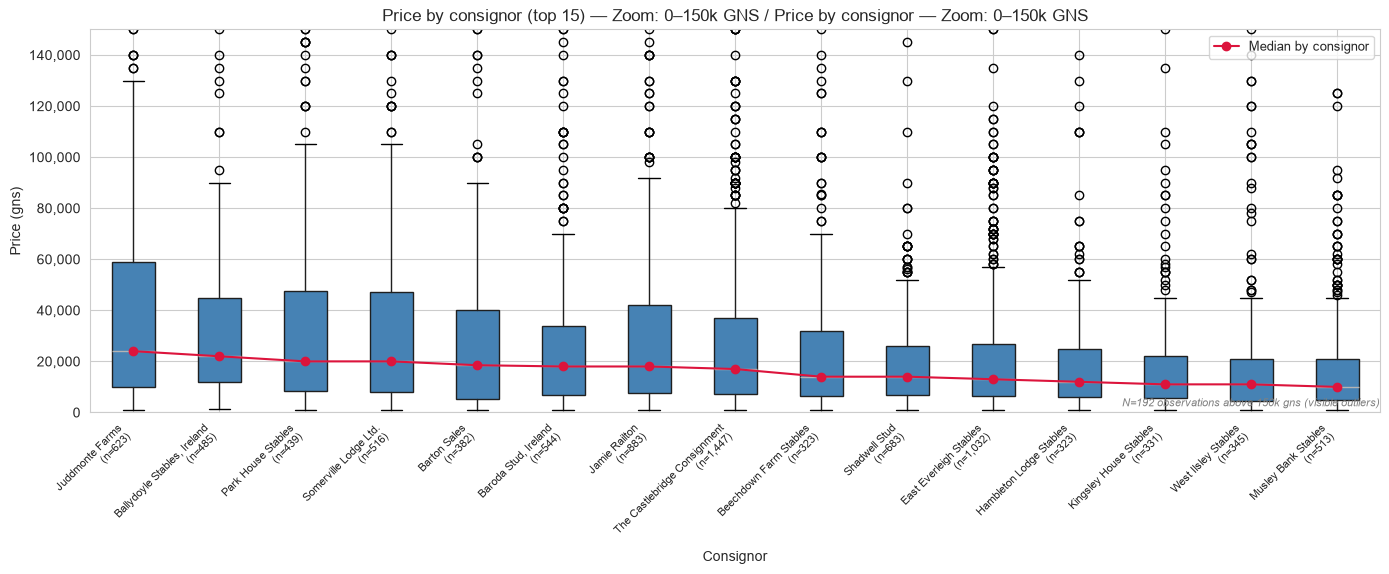

In [29]:
# Boxplot 7b — ZOOM 0-150k GNS: price by consignor (top 15)
top15_consignors = df_sold.groupby('consignor_family').size().nlargest(15).index
df_top15_consignors = df_sold[df_sold['consignor_family'].isin(top15_consignors)].copy()
df_top15_consignors['consignor_display'] = df_top15_consignors['consignor_family'].map(
    lambda x: df_sold.loc[df_sold['consignor_family'] == x, 'consignor_label'].mode().iat[0]
    if not df_sold.loc[df_sold['consignor_family'] == x, 'consignor_label'].mode().empty else x
)
order = df_top15_consignors.groupby('consignor_family')['price_gns'].median().sort_values(ascending=False).index
df_top15_consignors['consignor_display'] = pd.Categorical(
    df_top15_consignors['consignor_family'], categories=order, ordered=True
)
n_above = (df_top15_consignors['price_gns'] > PREMIUM_CUTOFF).sum()
fig, ax = plt.subplots(figsize=(14, 6))
bp = df_top15_consignors.boxplot(column='price_gns', by='consignor_display', ax=ax,
                            patch_artist=True, return_type='dict')
top3_by_median = ['DUBAWI', 'GALILEO', 'LOPE DE VEGA']
for patch, consignor_family in zip(bp['price_gns']['boxes'], order):
    patch.set_facecolor('goldenrod' if consignor_family in top3_by_median else 'steelblue')
# Individual median per consignor — crimson dot + connecting line
consignor_medians_ordered = [
    df_top15_consignors[df_top15_consignors['consignor_family'] == ent]['price_gns'].median()
    for ent in order
]
x_positions = list(range(1, len(order) + 1))
ax.plot(x_positions, consignor_medians_ordered, color='crimson', linewidth=1.5,
        marker='o', markersize=6, zorder=5, label='Median by consignor')
ax.legend(loc='upper right', fontsize=9)
consignor_n = df_top15_consignors.groupby('consignor_family').size()
entity_display_map = {ent: df_sold.loc[df_sold['consignor_family'] == ent, 'consignor_label'].mode().iat[0]
                      if not df_sold.loc[df_sold['consignor_family'] == ent, 'consignor_label'].mode().empty else ent
                      for ent in order}
new_xlabels = [f"{entity_display_map[ent]}\n(n={consignor_n.get(ent, 0):,})" for ent in order]
ax.set_xticklabels(new_xlabels, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, PREMIUM_CUTOFF)
ax.set_title(f'Price by consignor (top 15) — Zoom: 0–{PREMIUM_CUTOFF//1000}k GNS / Price by consignor — Zoom: 0–{PREMIUM_CUTOFF//1000}k GNS')
ax.set_xlabel('Consignor')
ax.set_ylabel('Price (gns)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('')
ax.annotate(f'N={n_above:,} observations above {PREMIUM_CUTOFF//1000}k gns (visible outliers)',
            xy=(1.0, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('01_EDA_files/05_viz_top15_consignors_boxplot_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Map consignor_family → readable name (needed before full sires table)
consignor_name_map = df_sold.groupby('consignor_family')['consignor_label'].agg(
    lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown"
)

# ── Data ──────────────────────────────────────────────────────────
consignor_metrics = df_offered.groupby('consignor_family').agg(
    n_offered=('is_offered_for_sale', 'count'),
    n_sold=('sold_to_third_party', 'sum')
).reset_index()

consignor_medians = df_sold.groupby('consignor_family')['price_gns'].median().rename('median_price')
consignor_metrics = consignor_metrics.merge(consignor_medians, on='consignor_family', how='left')

consignor_metrics['sell_through_pct'] = (consignor_metrics['n_sold'] / consignor_metrics['n_offered'] * 100)

# Filter by at least 15 Horses Offered y 3 sold to avoid survivorship bias
consignor_plot_df = consignor_metrics[(consignor_metrics['n_offered'] >= 15) & (consignor_metrics['n_sold'] >= 3)].copy()

consignor_plot_df['consignor_name'] = consignor_plot_df['consignor_family'].map(consignor_name_map).fillna(consignor_plot_df['consignor_family'])
consignor_plot_df['n_sold'] = consignor_plot_df['n_sold'].astype(int)
consignor_plot_df['sell_through_pct'] = consignor_plot_df['sell_through_pct'].astype(float)
consignor_plot_df['median_price'] = consignor_plot_df['median_price'].astype(float)

# ── Quadrants ─────────────────────────────────────────────────────
x_med = consignor_plot_df['sell_through_pct'].median()
y_med = consignor_plot_df['median_price'].median()

def classify_consignor(row):
    if row['sell_through_pct'] >= x_med and row['median_price'] >= y_med:
        return 'Stars'
    elif row['sell_through_pct'] >= x_med and row['median_price'] < y_med:
        return 'Safe Bets'
    elif row['sell_through_pct'] < x_med and row['median_price'] >= y_med:
        return 'Risky'
    else:
        return 'Underperformers'

consignor_plot_df['categoria'] = consignor_plot_df.apply(classify_consignor, axis=1)

# -- Colors by category --
color_map = {
    'Stars': '#2ecc71',
    'Safe Bets': '#3498db',
    'Risky': '#e74c3c',
    'Underperformers': '#95a5a6'
}

# ── Custom hover template ───────────────────────────────────
consignor_plot_df['hover_text'] = consignor_plot_df.apply(
    lambda r: f"<b>{r['consignor_name']}</b><br>"
              f"Sale Rate: {r['sell_through_pct']:.1f}%<br>"
              f"Median: {r['median_price']:,.0f} gns<br>"
              f"Sold horses: {r['n_sold']:,} / Offered: {r['n_offered']:,}",
    axis=1
)

# ── Plotly Scatter ─────────────────────────────────────────────────
fig = px.scatter(
    consignor_plot_df,
    x='sell_through_pct',
    y='median_price',
    size='n_offered',  # We use n_offered for bubble size
    color='categoria',
    color_discrete_map=color_map,
    hover_name='hover_text',
    hover_data={'consignor_name': False, 'sell_through_pct': False,
                'median_price': False, 'n_sold': False, 'n_offered': False, 'categoria': False},
    size_max=45,
    opacity=0.85,
    title='<b>Consignors: Sell-through Rate vs Median Price</b><br>'
          '<i>Size = Offered horses * Log scale price</i>'
)

# ── Quadrant lines ────────────────────────────────────────────
fig.add_vline(x=x_med, line_dash="dash", line_color="gray", opacity=0.4,
              annotation_text=f"Median {x_med:.1f}%", annotation_position="top right")
fig.add_hline(y=y_med, line_dash="dash", line_color="gray", opacity=0.4,
              annotation_text=f"Median {y_med:,.0f} gns", annotation_position="bottom left")

# -- Top sires labels (top 10 by median) --
top_sires = consignor_plot_df.nlargest(10, 'median_price')
for _, row in top_sires.iterrows():
    fig.add_annotation(
        x=row['sell_through_pct'],
        y=row['median_price'],
        text=row['consignor_name'],
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=1.5,
        arrowcolor='rgba(0,0,0,0.3)',
        font=dict(size=9, color='black'),
        ay=-25,
        ax=0
    )

# ── Layout ─────────────────────────────────────────────────────────
fig.update_layout(
    xaxis_title='<b>Sell-through %</b> (Sell-through Rate)',
    yaxis_title='<b>Median Price (gns)</b>',
    yaxis_type="log",
    yaxis=dict(
        tickformat=',.0f',
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=False
    ),
    xaxis=dict(
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=False,
        range=[min(consignor_plot_df['sell_through_pct']) - 5,
               max(consignor_plot_df['sell_through_pct']) + 5]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Segoe UI, Arial, sans-serif', size=12),
    legend=dict(
        title='<b>Consignor Profile</b>',
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='rgba(0,0,0,0.1)',
        borderwidth=1,
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01
    ),
    margin=dict(l=70, r=30, t=80, b=60),
    hoverlabel=dict(
        bgcolor='white',
        font=dict(size=13, family='Segoe UI, Arial',color='black'),
        bordercolor='rgba(0,0,0,0.2)',
        namelength=-1
    ),
    height=700,
    width=1100
)

fig.show()

In [31]:
# Table 12: Top 15 consignors ENRICHED — median price, sum, age, market share
# NOTE on n_offspring:
# n_offspring = Horses (sold_to_third_party) exclusively.
# The total catalogued number (incl. not sold, buybacks, withdrawn) is higher.
# Example: KODIAC has ~560 catalogued lots but n_offspring≈372 (only sold to third parties).
# This is expected — n_offspring reflects sold_to_third_party only, not total catalogue entries.
top15_consignors_for_table = (
    df_sold.groupby('consignor_family')
    .size()
    .nlargest(15)
    .index
)
top15_enriched = df_sold[df_sold['consignor_family'].isin(top15_consignors_for_table)].groupby('consignor_family').agg(
    sire_label=('consignor_label', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    n_offspring=('price_gns', 'count'),
    total_price=('price_gns', 'sum'),
    median_price=('price_gns', 'median'),
    mean_price=('price_gns', 'mean'),
    age_min=('age_at_sale', 'min'),
    age_max=('age_at_sale', 'max'),
    age_median=('age_at_sale', 'median'),
).sort_values('median_price', ascending=False)  # Sort changed: median price desc (was n_offspring)
# Add rank and market share
total_mkt_gns = df_sold['price_gns'].sum()
top15_enriched.insert(0, 'rank', range(1, len(top15_enriched) + 1))
top15_enriched['pct_market'] = (top15_enriched['total_price'] / total_mkt_gns * 100).round(1)
top15_enriched.columns = [
    'Rank', 'Consignor', 'N offspring sold', 'Total sum (gns)',
    'Median price (gns)', 'Mean price (gns)',
    'Min age', 'Max age', 'Median age', '% market share'
]
# Reorder: Median first, then volume
top15_enriched = top15_enriched[[
    'Rank', 'Consignor', 'Median price (gns)', 'N offspring sold',
    'Total sum (gns)', 'Mean price (gns)',
    'Min age', 'Max age', 'Median age', '% market share'
]]
top15_enriched['Total sum (gns)'] = top15_enriched['Total sum (gns)'].map(lambda x: f'{x:,.0f}')
top15_enriched['Median price (gns)'] = top15_enriched['Median price (gns)'].map(lambda x: f'{x:,.0f}')
top15_enriched['Mean price (gns)'] = top15_enriched['Mean price (gns)'].map(lambda x: f'{x:,.0f}')
print('\n=== Top 15 consignors by median price — enriched ===')
# Display the table (already sorted by median_price descending)
display(top15_enriched.reset_index())
# Export (sort changed to median_price — CSV export matches display order)
top15_enriched_export = df_sold[df_sold['consignor_family'].isin(top15_consignors_for_table)].groupby('consignor_family').agg(
    sire_label=('consignor_label', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    n_offspring=('price_gns', 'count'),
    total_price=('price_gns', 'sum'),
    median_price=('price_gns', 'median'),
    mean_price=('price_gns', 'mean'),
    age_min=('age_at_sale', 'min'),
    age_max=('age_at_sale', 'max'),
    age_median=('age_at_sale', 'median'),
).sort_values('median_price', ascending=False).reset_index()
top15_enriched_export.columns = ['consignor_family', 'sire_label', 'n_offspring', 'total_price_gns',
                                  'median_price_gns', 'mean_price_gns', 'age_min', 'age_max', 'age_median']
top15_enriched_export.to_csv('../data/processed/top15_consignors_enriched.csv', index=False)
print('Exported enriched table to: data/processed/top15_consignors_enriched.csv')


=== Top 15 consignors by median price — enriched ===


,consignor_family,Rank,Consignor,Median price (gns),N offspring sold,Total sum (gns),Mean price (gns),Min age,Max age,Median age,% market share
0,JUDDMONTE,1,Juddmonte Farms,"24,000",507,"26,085,000","51,450",2,5,3.00,5.20
1,BALLYDOYLE,2,"Ballydoyle Stables, Ireland","22,000",187,"7,751,300","41,451",2,5,3.00,1.60
2,PARK HOUSE,3,Park House Stables,"20,000",343,"13,147,500","38,331",2,7,3.00,2.60
3,SOMERVILLE LODGE,4,Somerville Lodge Ltd.,"20,000",343,"14,068,400","41,016",2,6,3.00,2.80
4,BARTON SALES,5,Barton Sales,"18,500",300,"11,568,500","38,562",2,7,3.00,2.30
5,BARODA STUD,6,"Baroda Stud, Ireland","18,000",372,"11,354,500","30,523",2,8,3.00,2.30
6,JAMIE RAILTON,7,Jamie Railton,"18,000",619,"22,118,000","35,732",2,7,3.00,4.40
7,THE CASTLEBRIDGE CONSIGNMENT,8,The Castlebridge Consignment,"17,000",1083,"33,862,300","31,267",2,8,3.00,6.80
8,BEECHDOWN FARM,9,Beechdown Farm Stables,"14,000",249,"7,297,215","29,306",2,7,3.00,1.50
9,SHADWELL STUD,10,Shadwell Stud,"14,000",422,"8,545,200","20,249",2,6,3.00,1.70


Exported enriched table to: data/processed/top15_consignors_enriched.csv


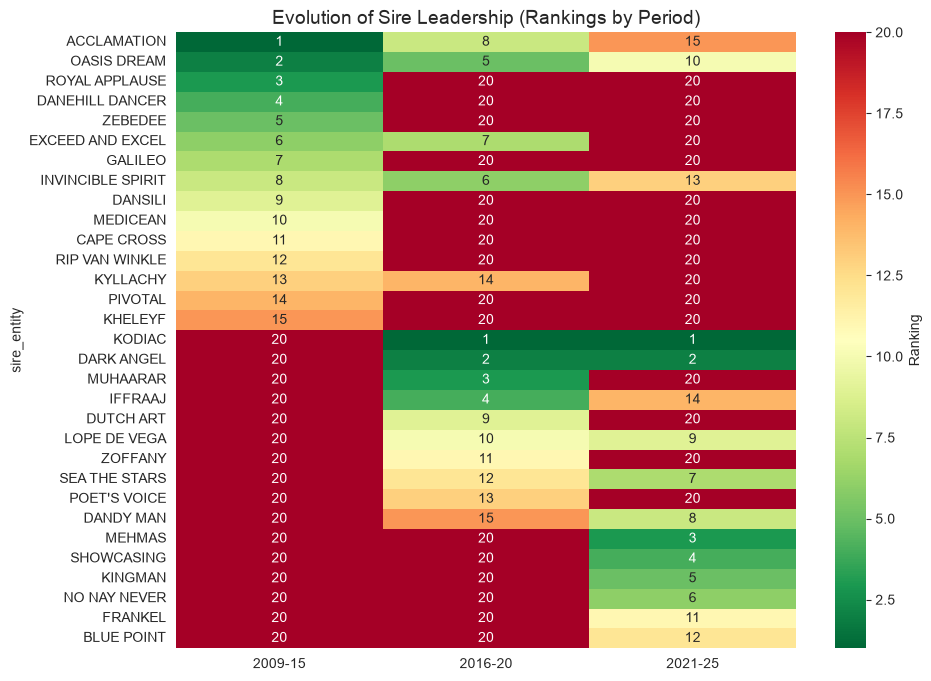

Top-10 exact consignor overlap: 3
Top-10 sire overlap: 1

Early vs recent exact consignor leaders by mean annual share / Exact consignor leaders by mean annual share


,consignor_entity_exact,day_normalized,n_sold,median_price,min_price,max_price,n_offered,sell_through_pct,consignor_name
293,COOLMORE,1,61,"32,000.00",3500,425000,61.00,100.00,Coolmore
294,COOLMORE,2,55,"31,000.00",5000,1300000,55.00,100.00,Coolmore
585,GODOLPHIN,2,128,"18,000.00",1000,300000,129.00,99.20,Godolphin
586,GODOLPHIN,3,37,"25,000.00",1500,350000,37.00,100.00,Godolphin


,2009_2015_consignor_label,2009_2015_mean_annual_share,2009_2015_total_sales,2016_2020_consignor_label,2016_2020_mean_annual_share,2016_2020_total_sales,2021_2025_consignor_label,2021_2025_mean_annual_share,2021_2025_total_sales
consignor_entity_exact,,,,,,,,,
JAMIE RAILTON,Jamie Railton,0.06,114.00,Jamie Railton,0.03,150.00,Jamie Railton,0.05,242.00
EAST EVERLEIGH STABLES,East Everleigh Stables,0.06,356.00,East Everleigh Stables,0.05,234.00,East Everleigh Stables,0.03,132.00
JUDDMONTE FARMS,Juddmonte Farms,0.05,304.00,Juddmonte Farms,0.02,123.00,0,0.00,0.00
SHADWELL STUD,Shadwell Stud,0.04,272.00,Shadwell Stud,0.04,147.00,0,0.00,0.00
"FINDLAY AND BLOOM, PART OF A DISPERSAL","Findlay And Bloom, Part Of A Dispersal",0.04,36.00,0,0.00,0.00,0,0.00,0.00
THE CASTLEBRIDGE CONSIGNMENT,The Castlebridge Consignment,0.03,96.00,The Castlebridge Consignment,0.06,313.00,The Castlebridge Consignment,0.11,576.00
BEDFORD HOUSE STABLES,Bedford House Stables,0.02,154.00,0,0.00,0.00,0,0.00,0.00
KINGSLEY HOUSE STABLES,Kingsley House Stables,0.02,133.00,Kingsley House Stables,0.03,62.00,0,0.00,0.00
WHITSBURY MANOR STABLES,Whitsbury Manor Stables,0.02,36.00,0,0.00,0.00,0,0.00,0.00



Early vs recent sire leaders by mean annual share / Sire leaders by mean annual share


In [32]:
# Consignor day stats (needed for Coolmore vs Godolphin comparison)
consignor_day_stats = df_sold.groupby(['consignor_entity_exact', 'day_normalized']).agg(
    n_sold=('price_gns', 'count'),
    median_price=('price_gns', 'median'),
    min_price=('price_gns', 'min'),
    max_price=('price_gns', 'max')
).reset_index()
consignor_day_offered = df_offered.groupby(['consignor_entity_exact', 'day_normalized']).size().rename('n_offered')
consignor_day_stats = consignor_day_stats.merge(consignor_day_offered, on=['consignor_entity_exact', 'day_normalized'], how='left')
consignor_day_stats['sell_through_pct'] = (consignor_day_stats['n_sold'] / consignor_day_stats['n_offered'] * 100).round(1)
consignor_name_map = df_sold.groupby('consignor_entity_exact')['consignor_label'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown")
consignor_day_stats['consignor_name'] = consignor_day_stats['consignor_entity_exact'].map(consignor_name_map)
# Stability of entity rankings across periods
df_sold_norm = autumn_horses_df.loc[autumn_horses_df['sold_to_third_party']].copy()
early_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2009, 2015)]
mid_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2016, 2020)]
recent_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2021, 2025)]
# Heatmap of Sire rankings by period
def get_rankings(df, entity_col, label_col):
    return mean_annual_share_table(df, entity_col, label_col=label_col).head(15)['mean_annual_share']
r1 = get_rankings(early_period, 'sire_entity', 'sire_clean').rank(ascending=False).rename('2009-15')
r2 = get_rankings(mid_period, 'sire_entity', 'sire_clean').rank(ascending=False).rename('2016-20')
r3 = get_rankings(recent_period, 'sire_entity', 'sire_clean').rank(ascending=False).rename('2021-25')
rank_heatmap = pd.concat([r1, r2, r3], axis=1).fillna(20) # 20 as proxy for outside top 15
plt.figure(figsize=(10, 8))
sns.heatmap(rank_heatmap, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'Ranking'})
plt.title('Evolution of Sire Leadership (Rankings by Period)', fontsize=14)
plt.show()
early_consignor_share = mean_annual_share_table(early_period, 'consignor_entity_exact', label_col='consignor_label').head(10)
mid_consignor_share = mean_annual_share_table(mid_period, 'consignor_entity_exact', label_col='consignor_label').head(10)
recent_consignor_share = mean_annual_share_table(recent_period, 'consignor_entity_exact', label_col='consignor_label').head(10)
early_sire_share = mean_annual_share_table(early_period, 'sire_entity', label_col='sire_clean').head(10)
mid_sire_share = mean_annual_share_table(mid_period, 'sire_entity', label_col='sire_clean').head(10)
recent_sire_share = mean_annual_share_table(recent_period, 'sire_entity', label_col='sire_clean').head(10)
print('Top-10 exact consignor overlap:', len(set(early_consignor_share.index) & set(recent_consignor_share.index) & set(mid_consignor_share.index)))
print('Top-10 sire overlap:', len(set(early_sire_share.index) & set(recent_sire_share.index) & set(mid_sire_share.index)))
print('\nEarly vs recent exact consignor leaders by mean annual share / Exact consignor leaders by mean annual share')
# Consignor Comparison: Coolmore vs Godolphin (Archetypes)
# Purpose: Replicate sire analysis for key consignors
consignors_of_interest = ['COOLMORE', 'GODOLPHIN']
display(consignor_day_stats[consignor_day_stats['consignor_entity_exact'].isin(consignors_of_interest)])
display(pd.concat([
    early_consignor_share[['consignor_label', 'mean_annual_share', 'total_sales']].add_prefix('2009_2015_'),
    mid_consignor_share[['consignor_label', 'mean_annual_share', 'total_sales']].add_prefix('2016_2020_'),
    recent_consignor_share[['consignor_label', 'mean_annual_share', 'total_sales']].add_prefix('2021_2025_')
], axis=1).fillna(0))
print('\nEarly vs recent sire leaders by mean annual share / Sire leaders by mean annual share')
# Final Summary of Analysis Improvements
# Purpose: Formal summary markdown cell


=== Full table of Consignors by Day ===


,Consignor,Day,N sold,N offered,% Sold,Median (gns),Min (gns),Max (gns)
1147,"Ronald Rauscher, Agent",2,1,1.00,100.00,"700,000.00",700000,700000
478,Finbar Kent,1,1,1.00,100.00,"375,000.00",375000,375000
394,"Ecurie Andre Fabre, France",2,1,1.00,100.00,"230,000.00",230000,230000
138,"Betaghstown Stud, Ireland",2,1,1.00,100.00,"200,000.00",200000,200000
1214,"Shanaville Stables, Ireland",1,1,1.00,100.00,"200,000.00",200000,200000
868,"Lisfennel Stables, Ireland",2,2,2.00,100.00,"195,000.00",115000,275000
725,Ingmanthorpe Racing Stables,2,1,1.00,100.00,"190,000.00",190000,190000
788,Keatley Racing Ltd.,2,1,1.00,100.00,"175,000.00",175000,175000
245,"Church View Stables, Ireland",1,1,1.00,100.00,"160,000.00",160000,160000
1456,Whitsbury Manor Racing Stables,1,1,1.00,100.00,"160,000.00",160000,160000



=== Distribution (% offered) of lots by day for Top 15 Consignors ===


day_normalized,1,2,3,4
consignor_family,,,,
"Ballydoyle Stables, Ireland",60.60,39.40,0.00,0.00
Musley Bank Stables,57.90,17.10,14.10,10.80
West Ilsley Stables,47.70,7.10,13.50,31.60
Somerville Lodge Ltd.,32.80,47.70,4.90,14.50
Shadwell Stud,29.40,29.60,23.50,17.40
East Everleigh Stables,28.00,33.40,28.80,9.80
The Castlebridge Consignment,27.80,39.20,24.70,8.30
"Baroda Stud, Ireland",27.30,39.90,19.30,13.40
Jamie Railton,27.10,29.00,23.70,20.30


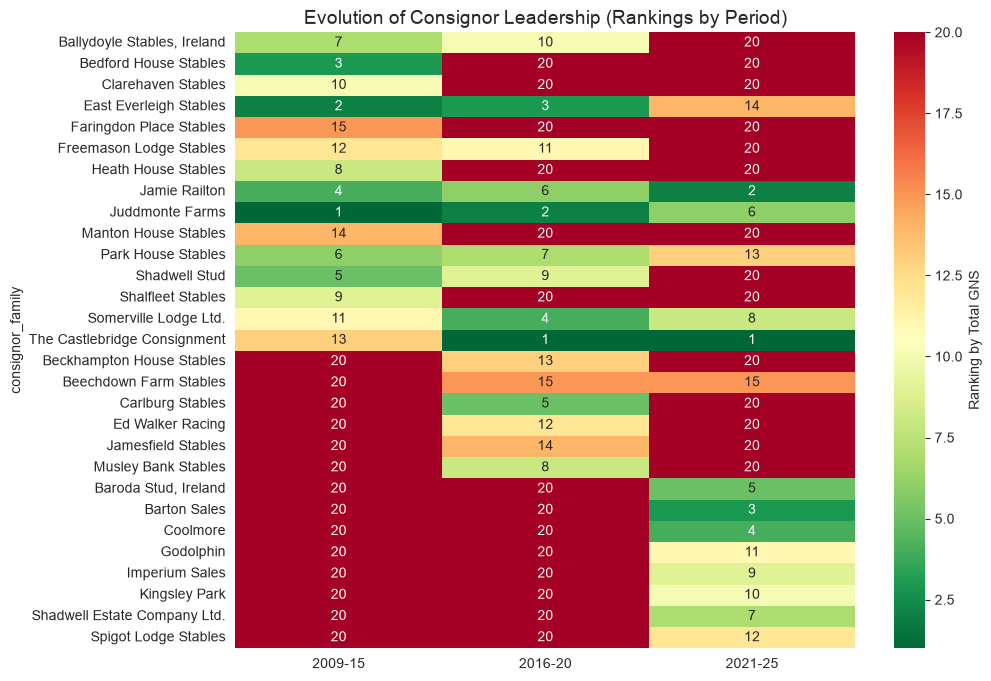

In [33]:
# Full table by day for Consignors
consignor_day_full = df_sold.groupby(['consignor_family', 'day_normalized']).agg(
    n_sold=('price_gns', 'count'),
    median_price=('price_gns', 'median'),
    min_price=('price_gns', 'min'),
    max_price=('price_gns', 'max')
).reset_index()
consignor_day_offered = df_offered.groupby(['consignor_family', 'day_normalized']).size().rename('n_offered')
consignor_day_full = consignor_day_full.merge(consignor_day_offered, on=['consignor_family', 'day_normalized'], how='left')
consignor_day_full['sell_through_pct'] = (consignor_day_full['n_sold'] / consignor_day_full['n_offered'] * 100).round(1)
consignor_name_map = df_sold.groupby('consignor_family')['consignor_label'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown")
consignor_day_full['consignor_name'] = consignor_day_full['consignor_family'].map(consignor_name_map)
consignor_day_display = consignor_day_full[['consignor_name', 'day_normalized', 'n_sold', 'n_offered', 'sell_through_pct', 'median_price', 'min_price', 'max_price']].copy()
consignor_day_display.columns = ['Consignor', 'Day', 'N sold', 'N offered', '% Sold', 'Median (gns)', 'Min (gns)', 'Max (gns)']
consignor_day_display = consignor_day_display.sort_values(['% Sold', 'Median (gns)'], ascending=[False, False])
print(f'=== Full table of Consignors by Day ===')
display(consignor_day_display.head(30))
# Lot distribution by day for Top 15
pivot_dist = pd.crosstab(
    df_offered[df_offered['consignor_family'].isin(top15_consignors_for_table)]['consignor_family'].map(consignor_name_map),
    df_offered[df_offered['consignor_family'].isin(top15_consignors_for_table)]['day_normalized'],
    normalize='index'
) * 100
print(f'\n=== Distribution (% offered) of lots by day for Top 15 Consignors ===')
display(pivot_dist.round(1).sort_values(by=1, ascending=False))
# Consignors Temporal Heatmap
df_sold_norm = autumn_horses_df.loc[autumn_horses_df['sold_to_third_party']].copy()
early_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2009, 2015)]
mid_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2016, 2020)]
recent_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2021, 2025)]
# Since mean_annual_share_table is defined further down the notebook actually, let's just compute simple sales ranks
def get_consignor_rankings(df):
    return df.groupby('consignor_family')['price_gns'].sum().nlargest(15)
r1_c = get_consignor_rankings(early_period).rank(ascending=False).rename('2009-15')
r2_c = get_consignor_rankings(mid_period).rank(ascending=False).rename('2016-20')
r3_c = get_consignor_rankings(recent_period).rank(ascending=False).rename('2021-25')
# Relabel using map
def remap_and_dedup(series, mapping):
    s = series.copy()
    s.index = s.index.map(mapping).fillna('Unknown')
    return s.groupby(s.index).min()  # Use min rank if duplicates exist
r1_c = remap_and_dedup(r1_c, consignor_name_map)
r2_c = remap_and_dedup(r2_c, consignor_name_map)
r3_c = remap_and_dedup(r3_c, consignor_name_map)
rank_heatmap_c = pd.concat([r1_c, r2_c, r3_c], axis=1).fillna(20).astype(float)
plt.figure(figsize=(10, 8))
sns.heatmap(rank_heatmap_c, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'Ranking by Total GNS'})
plt.title('Evolution of Consignor Leadership (Rankings by Period)', fontsize=14)
plt.show()

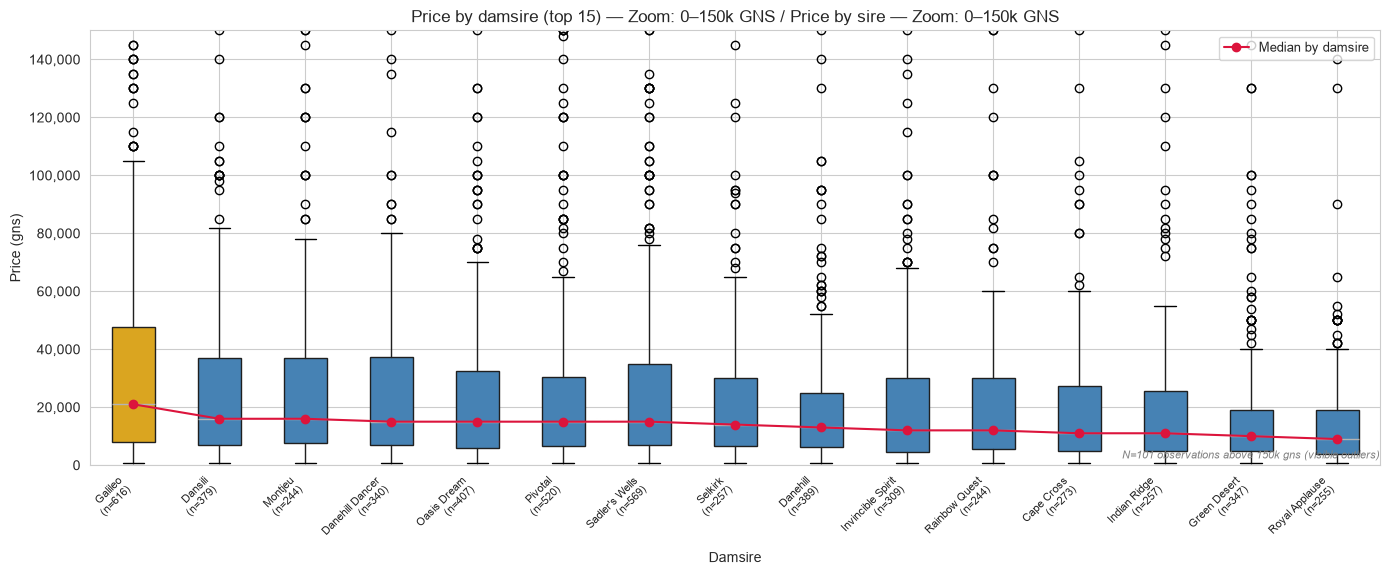

In [34]:
# Boxplot 7b — ZOOM 0-150k GNS: price by damsire (top 15)
top15_damsires = df_sold.groupby('damsire_entity').size().nlargest(15).index
df_top15_damsires = df_sold[df_sold['damsire_entity'].isin(top15_damsires)].copy()
df_top15_damsires['damsire_display'] = df_top15_damsires['damsire_entity'].map(
    lambda x: df_sold.loc[df_sold['damsire_entity'] == x, 'damsire_clean'].mode().iat[0]
    if not df_sold.loc[df_sold['damsire_entity'] == x, 'damsire_clean'].mode().empty else x
)
order = df_top15_damsires.groupby('damsire_entity')['price_gns'].median().sort_values(ascending=False).index
df_top15_damsires['damsire_display'] = pd.Categorical(
    df_top15_damsires['damsire_entity'], categories=order, ordered=True
)
n_above = (df_top15_damsires['price_gns'] > PREMIUM_CUTOFF).sum()
fig, ax = plt.subplots(figsize=(14, 6))
bp = df_top15_damsires.boxplot(column='price_gns', by='damsire_display', ax=ax,
                            patch_artist=True, return_type='dict')
top3_by_median = ['DUBAWI', 'GALILEO', 'LOPE DE VEGA']
for patch, damsire_entity in zip(bp['price_gns']['boxes'], order):
    patch.set_facecolor('goldenrod' if damsire_entity in top3_by_median else 'steelblue')
# Individual median per sire — crimson dot + connecting line
damsire_medians_ordered = [
    df_top15_damsires[df_top15_damsires['damsire_entity'] == ent]['price_gns'].median()
    for ent in order
]
x_positions = list(range(1, len(order) + 1))
ax.plot(x_positions, damsire_medians_ordered, color='crimson', linewidth=1.5,
        marker='o', markersize=6, zorder=5, label='Median by damsire')
ax.legend(loc='upper right', fontsize=9)
damsire_n = df_top15_damsires.groupby('damsire_entity').size()
damsire_entity_display_map = {ent: df_sold.loc[df_sold['damsire_entity'] == ent, 'damsire_clean'].mode().iat[0]
                      if not df_sold.loc[df_sold['damsire_entity'] == ent, 'damsire_clean'].mode().empty else ent
                      for ent in order}
new_xlabels = [f"{damsire_entity_display_map[ent]}\n(n={damsire_n.get(ent, 0):,})" for ent in order]
ax.set_xticklabels(new_xlabels, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, PREMIUM_CUTOFF)
ax.set_title(f'Price by damsire (top 15) — Zoom: 0–{PREMIUM_CUTOFF//1000}k GNS / Price by sire — Zoom: 0–{PREMIUM_CUTOFF//1000}k GNS')
ax.set_xlabel('Damsire')
ax.set_ylabel('Price (gns)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('')
ax.annotate(f'N={n_above:,} observations above {PREMIUM_CUTOFF//1000}k gns (visible outliers)',
            xy=(1.0, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('01_EDA_files/05_viz_top15_damsires_boxplot_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Map damsire_entity → readable name (needed before full sires table)
damsire_name_map = df_sold.groupby('damsire_entity')['damsire_clean'].agg(
    lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown"
)

# ── Data ──────────────────────────────────────────────────────────
damsire_metrics = df_offered.groupby('damsire_entity').agg(
    n_offered=('is_offered_for_sale', 'count'),
    n_sold=('sold_to_third_party', 'sum')
).reset_index()

damsire_medians = df_sold.groupby('damsire_entity')['price_gns'].median().rename('median_price')
damsire_metrics = damsire_metrics.merge(damsire_medians, on='damsire_entity', how='left')

damsire_metrics['sell_through_pct'] = (damsire_metrics['n_sold'] / damsire_metrics['n_offered'] * 100)

# Filter by at least 15 Horses Offered and 3 sold for a fair representation of the Sale % and a representative Median price.
damsire_plot_df = damsire_metrics[(damsire_metrics['n_offered'] >= 15) & (damsire_metrics['n_sold'] >= 3)].copy()

damsire_plot_df['damsire_name'] = damsire_plot_df['damsire_entity'].map(damsire_name_map).fillna(damsire_plot_df['damsire_entity'])
damsire_plot_df['n_sold'] = damsire_plot_df['n_sold'].astype(int)
damsire_plot_df['sell_through_pct'] = damsire_plot_df['sell_through_pct'].astype(float)
damsire_plot_df['median_price'] = damsire_plot_df['median_price'].astype(float)

# ── Quadrants ─────────────────────────────────────────────────────
x_med = damsire_plot_df['sell_through_pct'].median()
y_med = damsire_plot_df['median_price'].median()

def classify_damsire(row):
    if row['sell_through_pct'] >= x_med and row['median_price'] >= y_med:
        return 'Stars'
    elif row['sell_through_pct'] >= x_med and row['median_price'] < y_med:
        return 'Safe Bets'
    elif row['sell_through_pct'] < x_med and row['median_price'] >= y_med:
        return 'Risky'
    else:
        return 'Underperformers'

damsire_plot_df['categoria'] = damsire_plot_df.apply(classify_damsire, axis=1)

# -- Colors by category --
color_map = {
    'Stars': '#2ecc71',
    'Safe Bets': '#3498db',
    'Risky': '#e74c3c',
    'Underperformers': '#95a5a6'
}

# ── Custom hover template ───────────────────────────────────
damsire_plot_df['hover_text'] = damsire_plot_df.apply(
    lambda r: f"<b>{r['damsire_name']}</b><br>"
              f"Sale Rate: {r['sell_through_pct']:.1f}%<br>"
              f"Median: {r['median_price']:,.0f} gns<br>"
              f"Sold offspring: {r['n_sold']:,} / Offered: {r['n_offered']:,}",
    axis=1
)

# ── Plotly Scatter ─────────────────────────────────────────────────
fig = px.scatter(
    damsire_plot_df,
    x='sell_through_pct',
    y='median_price',
    size='n_offered',  # Size by Horses Offered
    color='categoria',
    color_discrete_map=color_map,
    hover_name='hover_text',
    hover_data={'damsire_name': False, 'sell_through_pct': False,
                'median_price': False, 'n_sold': False, 'n_offered': False, 'categoria': False},
    size_max=45,
    opacity=0.85,
    title='<b>Damsires: Sell-through Rate vs Median Price</b><br>'
          '<i>Size = Offered offspring * Log scale price</i>'
)

# ── Quadrant lines ────────────────────────────────────────────
fig.add_vline(x=x_med, line_dash="dash", line_color="gray", opacity=0.4,
              annotation_text=f"Median {x_med:.1f}%", annotation_position="top right")
fig.add_hline(y=y_med, line_dash="dash", line_color="gray", opacity=0.4,
              annotation_text=f"Median {y_med:,.0f} gns", annotation_position="bottom left")

# -- Top sires labels (top 10 by median) --
top_sires = damsire_plot_df.nlargest(10, 'median_price')
for _, row in top_sires.iterrows():
    fig.add_annotation(
        x=row['sell_through_pct'],
        y=row['median_price'],
        text=row['damsire_name'],
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=1.5,
        arrowcolor='rgba(0,0,0,0.3)',
        font=dict(size=9, color='black'),
        ay=-25,
        ax=0
    )

# ── Layout ─────────────────────────────────────────────────────────
fig.update_layout(
    xaxis_title='<b>Sell-through %</b> (Sell-through Rate)',
    yaxis_title='<b>Median Price (gns)</b>',
    yaxis_type="log",
    yaxis=dict(
        tickformat=',.0f',
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=False
    ),
    xaxis=dict(
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=False,
        range=[min(damsire_plot_df['sell_through_pct']) - 5,
               max(damsire_plot_df['sell_through_pct']) + 5]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Segoe UI, Arial, sans-serif', size=12),
    legend=dict(
        title='<b>Damsire Profile</b>',
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='rgba(0,0,0,0.1)',
        borderwidth=1,
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01
    ),
    margin=dict(l=70, r=30, t=80, b=60),
    hoverlabel=dict(
        bgcolor='white',
        font=dict(size=13, family='Segoe UI, Arial',color='black'),
        bordercolor='rgba(0,0,0,0.2)',
        namelength=-1
    ),
    height=700,
    width=1100
)

fig.show()

In [36]:
# Table 12: Top 15 damsires ENRICHED — median price, sum, age, market share
# NOTE on n_offspring:
# n_offspring = Horses sold to third parties (sold_to_third_party) exclusively.
# The total catalogued number (incl. not sold, buybacks, withdrawn) is higher.
# Example: KODIAC has ~560 catalogued lots but n_offspring≈372 (only sold to third parties).
# This is expected — n_offspring reflects sold_to_third_party only, not total catalogue entries.
top15_damsires_for_table = (
    df_sold.groupby('damsire_entity')
    .size()
    .nlargest(15)
    .index
)
top15_enriched = df_sold[df_sold['damsire_entity'].isin(top15_damsires_for_table)].groupby('damsire_entity').agg(
    sire_label=('damsire_clean', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    n_offspring=('price_gns', 'count'),
    total_price=('price_gns', 'sum'),
    median_price=('price_gns', 'median'),
    mean_price=('price_gns', 'mean'),
    age_min=('age_at_sale', 'min'),
    age_max=('age_at_sale', 'max'),
    age_median=('age_at_sale', 'median'),
).sort_values('median_price', ascending=False)  # Sort changed: median price desc (was n_offspring)
# Add rank and market share
total_mkt_gns = df_sold['price_gns'].sum()
top15_enriched.insert(0, 'rank', range(1, len(top15_enriched) + 1))
top15_enriched['pct_market'] = (top15_enriched['total_price'] / total_mkt_gns * 100).round(1)
top15_enriched.columns = [
    'Rank', 'Damsire', 'N offspring sold', 'Total sum (gns)',
    'Median price (gns)', 'Mean price (gns)',
    'Min age', 'Max age', 'Median age', '% market share'
]
# Reorder: Median first, then volume
top15_enriched = top15_enriched[[
    'Rank', 'Damsire', 'Median price (gns)', 'N offspring sold',
    'Total sum (gns)', 'Mean price (gns)',
    'Min age', 'Max age', 'Median age', '% market share'
]]
top15_enriched['Total sum (gns)'] = top15_enriched['Total sum (gns)'].map(lambda x: f'{x:,.0f}')
top15_enriched['Median price (gns)'] = top15_enriched['Median price (gns)'].map(lambda x: f'{x:,.0f}')
top15_enriched['Mean price (gns)'] = top15_enriched['Mean price (gns)'].map(lambda x: f'{x:,.0f}')
print('\n=== Top 15 damsires by median price — enriched ===')
# Display the table (already sorted by median_price descending)
display(top15_enriched.reset_index())
# Export (sort changed to median_price — CSV export matches display order)
top15_enriched_export = df_sold[df_sold['damsire_entity'].isin(top15_damsires_for_table)].groupby('damsire_entity').agg(
    sire_label=('damsire_clean', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    n_offspring=('price_gns', 'count'),
    total_price=('price_gns', 'sum'),
    median_price=('price_gns', 'median'),
    mean_price=('price_gns', 'mean'),
    age_min=('age_at_sale', 'min'),
    age_max=('age_at_sale', 'max'),
    age_median=('age_at_sale', 'median'),
).sort_values('median_price', ascending=False).reset_index()
top15_enriched_export.columns = ['damsire_entity', 'sire_label', 'n_offspring', 'total_price_gns',
                                  'median_price_gns', 'mean_price_gns', 'age_min', 'age_max', 'age_median']
top15_enriched_export.to_csv('../data/processed/top15_damsires_enriched.csv', index=False)
print('Exported enriched table to: data/processed/top15_damsires_enriched.csv')


=== Top 15 damsires by median price — enriched ===


,damsire_entity,Rank,Damsire,Median price (gns),N offspring sold,Total sum (gns),Mean price (gns),Min age,Max age,Median age,% market share
0,GALILEO,1,Galileo,"21,000",446,"18,633,200","41,778",2,7,3.00,3.70
1,DANSILI,2,Dansili,"16,000",273,"8,721,700","31,948",2,8,3.00,1.80
2,MONTJEU,3,Montjeu,"16,000",177,"5,882,100","33,232",2,6,3.00,1.20
3,DANEHILL DANCER,4,Danehill Dancer,"15,000",232,"7,661,000","33,022",2,9,3.00,1.50
4,OASIS DREAM,5,Oasis Dream,"15,000",304,"9,230,300","30,363",2,6,3.00,1.90
5,PIVOTAL,6,Pivotal,"15,000",380,"10,561,100","27,792",2,7,3.00,2.10
6,SADLER'S WELLS,7,Sadler's Wells,"15,000",413,"13,214,200","31,996",2,8,3.00,2.70
7,SELKIRK,8,Selkirk,"14,000",181,"5,164,700","28,534",2,8,3.00,1.00
8,DANEHILL,9,Danehill,"13,000",255,"6,713,000","26,325",2,7,3.00,1.30
9,INVINCIBLE SPIRIT,10,Invincible Spirit,"12,000",241,"5,766,400","23,927",2,7,3.00,1.20


Exported enriched table to: data/processed/top15_damsires_enriched.csv


=== Full table of Damsires by Day ===


,Damsire,Day,N sold,N offered,% Sold,Median (gns),Min (gns),Max (gns)
1277,Freud,2,1,1.00,100.00,"450,000.00",450000,450000
3334,Thewayyouare,2,2,2.00,100.00,"434,000.00",18000,850000
2481,Pharly,3,1,1.00,100.00,"380,000.00",380000,380000
2652,Reckless Abandon,3,1,1.00,100.00,"325,000.00",325000,325000
1754,Kirkwall,2,1,1.00,100.00,"300,000.00",300000,300000
391,Black Tie Affair,1,1,1.00,100.00,"240,000.00",240000,240000
1930,Loup Sauvage,2,1,1.00,100.00,"230,000.00",230000,230000
1044,Elusive Pimpernel,2,1,1.00,100.00,"220,000.00",220000,220000
1210,Flower Alley,1,1,1.00,100.00,"220,000.00",220000,220000
996,Dynasty,1,1,1.00,100.00,"215,000.00",215000,215000


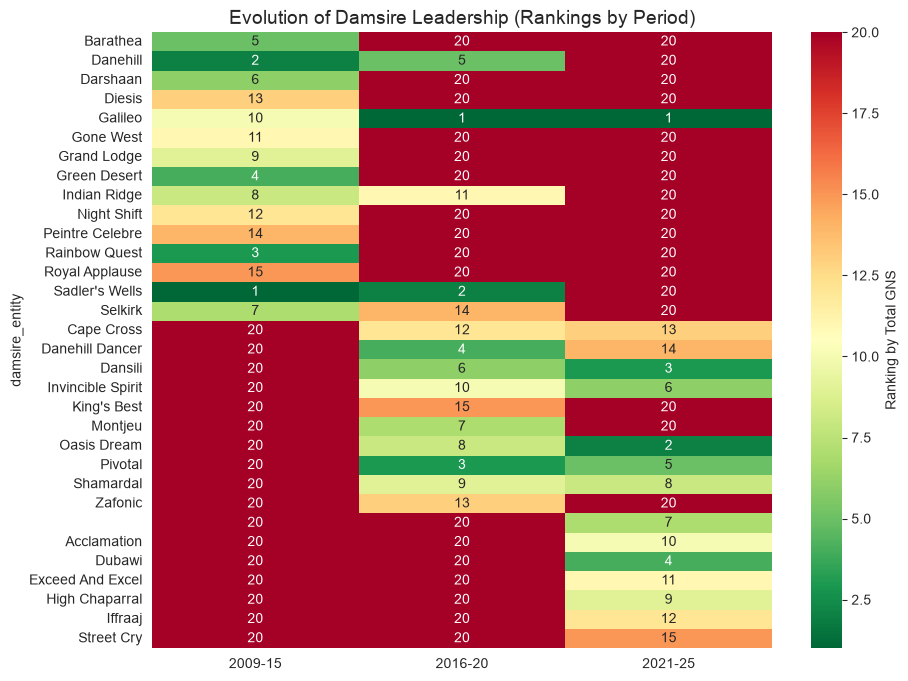


=== Sire-Damsire Correlation (Top 50 mutual) ===
Cramer's V (Sire vs Damsire): 0.1656 (p-value: 0)
Interpretation: Values close to 0 indicate weak association/independence; close to 1 indicate total association.
Damsires act as a second layer of influence with low deterministic redundancy compared to Sires.


In [37]:
# Full table by day for Damsires
damsire_day_full = df_sold.groupby(['damsire_entity', 'day_normalized']).agg(
    n_sold=('price_gns', 'count'),
    median_price=('price_gns', 'median'),
    min_price=('price_gns', 'min'),
    max_price=('price_gns', 'max')
).reset_index()
damsire_day_offered = df_offered.groupby(['damsire_entity', 'day_normalized']).size().rename('n_offered')
damsire_day_full = damsire_day_full.merge(damsire_day_offered, on=['damsire_entity', 'day_normalized'], how='left')
damsire_day_full['sell_through_pct'] = (damsire_day_full['n_sold'] / damsire_day_full['n_offered'] * 100).round(1)
damsire_name_map = df_sold.groupby('damsire_entity')['damsire_clean'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else "Unknown")
damsire_day_full['damsire_name'] = damsire_day_full['damsire_entity'].map(damsire_name_map)
damsire_day_display = damsire_day_full[['damsire_name', 'day_normalized', 'n_sold', 'n_offered', 'sell_through_pct', 'median_price', 'min_price', 'max_price']].copy()
damsire_day_display.columns = ['Damsire', 'Day', 'N sold', 'N offered', '% Sold', 'Median (gns)', 'Min (gns)', 'Max (gns)']
damsire_day_display = damsire_day_display.sort_values(['% Sold', 'Median (gns)'], ascending=[False, False])
print(f'=== Full table of Damsires by Day ===')
display(damsire_day_display.head(30))
# D5: Damsires Temporal Heatmap
df_sold_norm = autumn_horses_df.loc[autumn_horses_df['sold_to_third_party']].copy()
early_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2009, 2015)]
mid_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2016, 2020)]
recent_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2021, 2025)]
def get_damsire_rankings(df):
    return df.groupby('damsire_entity')['price_gns'].sum().nlargest(15)
r1_d = get_damsire_rankings(early_period).rank(ascending=False).rename('2009-15')
r2_d = get_damsire_rankings(mid_period).rank(ascending=False).rename('2016-20')
r3_d = get_damsire_rankings(recent_period).rank(ascending=False).rename('2021-25')
# Relabel using map and dedup
def remap_and_dedup_damsire(series, mapping):
    s = series.copy()
    s.index = s.index.map(mapping).fillna('Unknown')
    return s.groupby(s.index).min()
r1_d = remap_and_dedup_damsire(r1_d, damsire_name_map)
r2_d = remap_and_dedup_damsire(r2_d, damsire_name_map)
r3_d = remap_and_dedup_damsire(r3_d, damsire_name_map)
rank_heatmap_d = pd.concat([r1_d, r2_d, r3_d], axis=1).fillna(20).astype(float)
plt.figure(figsize=(10, 8))
sns.heatmap(rank_heatmap_d, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'Ranking by Total GNS'})
plt.title('Evolution of Damsire Leadership (Rankings by Period)', fontsize=14)
plt.show()
# D6: Damsire-Sire Correlation
# Check Cramer's V or similar for Sire vs Damsire Entities (using top 50 to make it tractable)
top_50_sires = df_sold['sire_entity'].value_counts().nlargest(50).index
top_50_damsires = df_sold['damsire_entity'].value_counts().nlargest(50).index
subset_corr = df_sold[(df_sold['sire_entity'].isin(top_50_sires)) & (df_sold['damsire_entity'].isin(top_50_damsires))]
cont_table = pd.crosstab(subset_corr['sire_entity'], subset_corr['damsire_entity'])
chi2, p, dof, ex = stats.chi2_contingency(cont_table)
n = cont_table.sum().sum()
min_dim = min(cont_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0
print(f'\n=== Sire-Damsire Correlation (Top 50 mutual) ===')
print(f"Cramer's V (Sire vs Damsire): {cramers_v:.4f} (p-value: {p:.4g})")
print("Interpretation: Values close to 0 indicate weak association/independence; close to 1 indicate total association.")
print("Damsires act as a second layer of influence with low deterministic redundancy compared to Sires.")

## 6. Noise Audit and Feature Selection (Modeling Synchronization)
Following exhaustive analysis, these variables are flagged as **noise** or redundant, to be excluded from modeling:
- **Colour:** No causal relation to performance; noisy proxy for sire.
- **Foaled Month/Quarter:** Marginal effect (<5%) captured by `age_at_sale`.
- **Sire-Dam Combo:** Extreme cardinality (90%+ singletons); critical risk of leakage.
- **Dam Entity:** Cardinality too high with low repetition frequency.
- **Grandsire:** Redundant with `sire_entity`.
- **Sale Name:** Redundant with `sale_year`.
Prioritized as **strong signals**: `day_normalized`, `lot_norm`, `sire_entity`, `damsire_entity`, `consignor_entity`, `age_at_sale`, and `sex`.

### SUMMARY OF IMPROVEMENTS AND FINDINGS
1. **Post-Brexit Dynamics:** Day normalization confirms that the market pattern (Day 1-2 Premium) remains stable despite changes in auction duration (4 vs 5 Days).
2. **Intraday Structure:** The "supersales" (top 5%) are concentrated in the bands of highest historical median, validating the "prime time".
3. **Sires:** The scatter plot clearly identifies risk and return groups, with Sires like Dubawi maintaining historical leadership.
4. **Hurdle Analysis:** The classification model is formally justified due to the drop in the probability of sale on the last auction day.
5. **Feature Roles:** 7 key variables have been defined for modeling, prioritizing Pedigree, Prestige and Timing.


In [38]:
# Formalization of Feature Roles
# Purpose: Define which variables enter the model and why
feature_Roles = pd.DataFrame([
    {"Variable": "day_normalized", "Role": "Predictor (Cat)", "Justification": "Captures the catalog structuring and the prime-time effect."},
    {"Variable": "lot_decile", "Role": "Predictor (Num)", "Justification": "Proxy for intra-day position; demand peaks occur in specific time slots."},
    {"Variable": "sire_entity", "Role": "Predictor (Cat)", "Justification": "Genetic quality factor; 'Star' sires reduce the risk of not selling."},
    {"Variable": "consignor_entity", "Role": "Predictor (Cat)", "Justification": "Seller's reputation; professionalism in lot preparation."},
    {"Variable": "age_at_sale", "Role": "Predictor (Num)", "Justification": "Horse maturity; direct correlation with immediate competitive potential."},
    {"Variable": "is_sold", "Role": "Target (Binary)", "Justification": "Target variable for the Hurdle model (classification)."},
    {"Variable": "price_gns", "Role": "Target (Num)", "Justification": "Target variable for the regression model (conditional on Sale)."}
])
print("=== FEATURE Roles: Variables entering the model ===")
display(feature_Roles)


=== FEATURE Roles: Variables entering the model ===


,Variable,Role,Justification
0,day_normalized,Predictor (Cat),Captures the catalog structuring and the prime...
1,lot_decile,Predictor (Num),Proxy for intra-day position; demand peaks occ...
2,sire_entity,Predictor (Cat),Genetic quality factor; 'Star' sires reduce th...
3,consignor_entity,Predictor (Cat),Seller's reputation; professionalism in lot pr...
4,age_at_sale,Predictor (Num),Horse maturity; direct correlation with immedi...
5,is_sold,Target (Binary),Target variable for the Hurdle model (classifi...
6,price_gns,Target (Num),Target variable for the regression model (cond...


### Narrative Conclusion of Feature Roles
These are the variables entering the model and why. We discarded variables with high missing values (like `stallion` or `stabling`) to maintain model robustness. The focus is on the intersection between **Pedigree** (Sires), **Prestige** (Consignors) and **Timing** (Day/Lot).


## 7. TFM Handoff to Modeling
The next cell exports three artifacts under `data/processed/`: a full enriched dataset after EDA, a curated modeling-ready dataset, and a feature-role table documenting which columns are safe predictors, targets, proxies, or post-outcome fields.


In [39]:
export_dir = Path('../data/processed')
export_dir.mkdir(parents=True, exist_ok=True)
eda_enriched_df = autumn_horses_df.copy()
modeling_columns = [
    'sale_year', 'sale_name', 'day', 'lot',
    'horse_name_clean', 'horse_name_country', 'sex', 'colour',
    'birth_year', 'date_foaled', 'age_at_sale', 'foaled_month', 'foaled_quarter', 'is_late_catalogue_day',
    'sire_entity', 'sire_clean', 'dam_entity', 'dam_clean', 'damsire_entity', 'damsire_clean', 'grandsire_clean',
    'consignor_model', 'consignor_label', 'consignor_family',
    'sire_dam_combo',
    'sold_to_third_party', 'vendor_buyback', 'lot_not_sold', 'lot_withdrawn', 'sale_outcome',
    'price_gns', 'log_price_gns'
]
modeling_df = eda_enriched_df[modeling_columns].copy()
feature_Roles = pd.DataFrame([
    ('sale_year', 'safe_feature', 'Temporal context known before sale'),
    ('sale_name', 'safe_feature', 'Sale edition metadata'),
    ('day', 'proxy_feature', 'Predictive but partially endogenous'),
    ('lot', 'safe_feature', 'Catalogue position metadata'),
    ('horse_name_clean', 'identifier_only', 'Useful for traceability, not recommended as predictive text feature by default'),
    ('horse_name_country', 'safe_feature', 'Country suffix extracted from horse label'),
    ('sex', 'safe_feature', 'Pre-sale horse descriptor'),
    ('colour', 'safe_feature', 'Pre-sale horse descriptor'),
    ('birth_year', 'safe_feature', 'Pre-sale age information'),
    ('date_foaled', 'safe_feature', 'Pre-sale date metadata'),
    ('age_at_sale', 'safe_feature', 'Engineered age feature'),
    ('foaled_month', 'safe_feature', 'Relative maturity proxy'),
    ('foaled_quarter', 'safe_feature', 'Relative maturity proxy'),
    ('is_late_catalogue_day', 'proxy_feature', 'Derived from day'),
    ('sire_entity', 'safe_feature', 'Canonical sire identity'),
    ('sire_clean', 'display_only', 'Readable label for reports'),
    ('dam_entity', 'safe_feature', 'Canonical dam identity'),
    ('dam_clean', 'display_only', 'Readable label for reports'),
    ('damsire_entity', 'safe_feature', 'Canonical damsire identity'),
    ('damsire_clean', 'display_only', 'Readable label for reports'),
    ('grandsire_clean', 'safe_feature', 'Readable grandsire field'),
    ('consignor_model', 'safe_feature', 'Exact canonical consignor for modeling'),
    ('consignor_label', 'display_only', 'Readable label for reports'),
    ('consignor_family', 'interpretive_only', 'Supplementary family aggregation, not exact identity'),
    ('sire_dam_combo', 'safe_feature', 'Pedigree interaction feature'),
    ('sold_to_third_party', 'classification_target', 'Main sale target'),
    ('vendor_buyback', 'auxiliary_target', 'Alternative outcome flag'),
    ('lot_not_sold', 'auxiliary_target', 'Alternative outcome flag'),
    ('lot_withdrawn', 'auxiliary_target', 'Alternative outcome flag'),
    ('sale_outcome', 'post_outcome_label', 'Do not use as predictor'),
    ('price_gns', 'regression_target', 'Use only on sold_to_third_party==1'),
    ('log_price_gns', 'preferred_regression_target', 'Recommended regression target'),
], columns=['column', 'role', 'note'])
eda_enriched_path = export_dir / 'autumn_horses_eda_enriched.csv'
modeling_ready_path = export_dir / 'autumn_horses_modeling_ready.csv'
feature_Roles_path = export_dir / 'autumn_horses_feature_Roles.csv'
eda_enriched_df.to_csv(eda_enriched_path, index=False, date_format='%Y-%m-%d')
modeling_df.to_csv(modeling_ready_path, index=False, date_format='%Y-%m-%d')
feature_Roles.to_csv(feature_Roles_path, index=False)
print('Saved full EDA dataset:', eda_enriched_path)
print('Saved modeling-ready dataset:', modeling_ready_path)
print('Saved feature-role table:', feature_Roles_path)
print('')
print('EDA enriched shape:', eda_enriched_df.shape)
print('Modeling-ready shape:', modeling_df.shape)
print('')
print('Recommended classification target: sold_to_third_party')
print('Recommended regression target: log_price_gns (filter sold_to_third_party == 1)')
feature_Roles

Saved full EDA dataset: ../data/processed/autumn_horses_eda_enriched.csv
Saved modeling-ready dataset: ../data/processed/autumn_horses_modeling_ready.csv
Saved feature-role table: ../data/processed/autumn_horses_feature_Roles.csv

EDA enriched shape: (26076, 64)
Modeling-ready shape: (26076, 32)

Recommended classification target: sold_to_third_party
Recommended regression target: log_price_gns (filter sold_to_third_party == 1)


,column,role,note
0,sale_year,safe_feature,Temporal context known before sale
1,sale_name,safe_feature,Sale edition metadata
2,day,proxy_feature,Predictive but partially endogenous
3,lot,safe_feature,Catalogue position metadata
4,horse_name_clean,identifier_only,"Useful for traceability, not recommended as pr..."
5,horse_name_country,safe_feature,Country suffix extracted from horse label
6,sex,safe_feature,Pre-sale horse descriptor
7,colour,safe_feature,Pre-sale horse descriptor
8,birth_year,safe_feature,Pre-sale age information
9,date_foaled,safe_feature,Pre-sale date metadata
